<a href="https://colab.research.google.com/github/bru401/Main/blob/main/MVP_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas_(Bruno_Reis).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas
## Análise Exploratória do Crime no Rio de Janeiro


**Nome:** Bruno Reis

**Matrícula:** 2026?????????

**Datasets:** [Estatísticas de segurança: série histórica mensal por área de delegacia desde 01/2003](https://www.ispdados.rj.gov.br/estatistica.html)
[População: série anual por área de delegacia (2000 a 2022)](https://www.ispdados.rj.gov.br/Populacao.html)

**---OBSERVAÇÕES IMPORTANTES---**

 Encorajamos você a usar a estrutura base deste Notebook para a construção das suas análises, já que ela contempla grande parte das sugestões do checklist no enunciado do MVP. Contudo, vale ressaltar que é necessário realizar mais etapas e análises, além das apresentadas neste notebook. É fundamental ter profundidade nas discussões e análises propostas, construindo um storytelling cativante que explore os principais conceitos e técnicas vistos nas aulas de Análise de Dados e Boas Práticas. **Este bloco de comentário com essas observações deve ser removido do seu projeto final**.

 **------**

# Descrição do Problema

*O dataset escolhido é uma série histórica que registra, por mês, a contagem de crimes em diferentes categorias e em diferentes localidades (as divisões territoriais RISP, AISP e CISP) dentro do estado do Rio de Janeiro - embora o trabalho em si contemple apenas o crime na capital. Este será complementado por um dataset que contribui com a população destas localidades, uma adição necessária para avaliar o crime per capita.*

*O objetivo principal é investigar as tendências histórias a respeito do tipo e a localidade do crime, e prever a continuidade destas através do treinamento de um modelo de regressão no futuro. Neste notebook serão realizadas apenas as etapas de análise de dados e pré-processamento.*

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **O crime no Rio de Janeiro proliferou acima do crescimento populacional? Onde? Em quais categorias?**
(Simples tendência na escala espacial e em categoria)

2. **Haveriam localidades 'outlier' em que o crime cresceu além da média da zona?**
(Granularidade do espaço geográfico)

3. **Haveriam tipos de crimes 'outlier' que cresceram além da média de suas categorias?**
(Granularidade do tipo exato de crime)

4. **Os tipos de crime mais frequentes significativamente divergem entre zonas?**

(WIP: algo que se refere ao tipo de treinamento de modelo; correlações; presunções)

## Tipo de Problema

Este é um problema de aprendizado **supervisionado** de **regressão**. O dataset consiste essencialmente de variáveis numéricas, com a excessão das colunas que registram o momento no tempo e o local dos registros, e com estes torna-se possível analisar as tendências de tais variáveis nas dimensões temporais e espaciais.

## Seleção de Dados

Ambos os datasets **"Estatísticas de segurança: série histórica mensal por área de delegacia desde 01/2003"** e **"População: série anual por área de delegacia (2000 a 2022)"** estão disponíveis livremente no site do ISPDados, uma página de dados abertos do Instituo de Segurança Pública, orgão do governo do estado do Rio de Janeiro.

## Atributos do Dataset

O dataset de estatísticas de segurança contém 36629 linhas e possui 54 atributos relacionados ao crime organizados em 8 categorias:

- ***Crimes Violentos***:
Homicídio doloso, Lesão corporal seguida de morte, Latrocínio (roubo seguido de morte), Crimes Violentos Letais Intencionais, Morte por intervenção de agente do Estado, Letalidade violenta, Tentativa de homicídio,  Lesão corporal dolosa,  Estupro.

- ***Crimes de Trânsito***: Homicídio culposo (trânsito), Lesão corporal culposa (trânsito).

- ***Roubos***: Roubo a transeunte, Roubo de telefone celular, Roubo em coletivo, Roubo de Rua, Roubo de veículo, Roubo de carga, Roubo a estabelecimento comercial, Roubo a residência, Roubo a banco, Roubo de caixa eletrônico, Roubo com condução da vítima para saque em instituição financeira, Roubo após saque em instituição financeira, Roubo de bicicleta, Outros roubos que não os listados acima, Total de roubos.

- ***Furtos***: Furto de veículo, Furto a transeunte, Furto em coletivo, Furto de telefone celular, Furto de bicicleta, Outros furtos que não os listados acima, Total de furtos.

- ***Outros crimes contra o patrimônio***: Extorsão mediante sequestro (sequestro clássico), Extorsão, Extorsão com momentânea privação da liberdade (sequestro relâmpago), Estelionato.

- ***Atividade Policial***: Apreensão de drogas, Número de registros que possuem algum título referente a posse de drogas
Número de registros que possuem algum título referente a tráfico de drogas, Número de registros que possuem algum título referente a apreensão de drogas sem autor, Recuperação de veículo, Auto de Prisão em Flagrante, Auto de Apreensão de Adolescente por Prática de Ato Infracional, Cumprimento de Mandado de Prisão, Cumprimento de Mandado de Busca e Apreensão.

- ***Outros Registros***: Ameaça, Pessoas desaparecidas, Encontro de cadáver, Encontro de ossada, Policiais Militares mortos em serviço, Policiais Civis mortos em serviço.

- ***Registro de ocorrências***

Um dicionário extenso de cada tipo de registro pode ser encontrado [aqui](https://www.ispdados.rj.gov.br/Notas.html)

<br>

### Divisões Territoriais
As divisões territoriais são demarcadas pelas colunas RISP, AISP e CISP:

- ***Regiões Integradas de Segurança Pública (RISP)***: as maiores divisões. São sete as RISPs do estado, com as RISP 1 e 2 pertencendo ao município do Rio.

- ***Áreas Integradas de Segurança Pública (AISP)***: as divisões intermediárias. Serve para a coordenação das políciais civil e militar.

- ***Circunscrições Integradas de Segurança Pública (CISP)***: são as divisões mais granulares, tipicamente contendo de 2 a 5 bairros. Relacionadas às delegacias.


# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Iris.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
# Guardando o dataset em um dataframe
#df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
#df['species'] = iris.target_names[iris.target]

# Estatísticas de segurança: série histórica mensal por área de delegacia desde 01/2003
df_estado = pd.read_csv("https://github.com/bru401/Main/raw/refs/heads/main/Data_Analytics/MVP_PUC-Rio/BaseDPEvolucaoMensalCisp.csv", sep=';', encoding = 'ISO-8859-1')

# População: série anual por área de delegacia (2000 a 2022)
dfpop = pd.read_csv("https://raw.githubusercontent.com/bru401/Main/refs/heads/main/Data_Analytics/MVP_PUC-Rio/PopulacaoEvolucaoAnualCisp.csv", sep=';', encoding = 'ISO-8859-1')

In [3]:
# Primeiras linhas (estatísticas de segurança)
df_estado.head()

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3


In [4]:
# Primeiras linhas (população)
dfpop.head()

,circ,ano,pop
0,1,2000,1516
1,4,2000,29229
2,5,2000,34985
3,6,2000,74835
4,7,2000,37931


In [5]:
dfpop.tail(5)

,circ,ano,pop
3060,159,2022,"59922,48804"
3061,165,2022,"44552,17238"
3062,166,2022,"204425,3032"
3063,167,2022,"43542,7503"
3064,168,2022,"18894,36465"


Note que os dados de população só chegam até 2022, enquanto os de crimes chegam a 2026. Não é um grande problema, visto que a população não muda tão rápido assim, mas é importante considerar isso.

O que *é* um problema é que população deveria ser um número inteiro.

In [6]:
dfpop.dtypes

,0
circ,int64
ano,int64
pop,object


In [7]:
# Passamos de string para float, arredondamos os valores e passamos de float para integer
dfpop['pop'] = (
    dfpop['pop']
    .str.replace(',', '.', regex=False)  # troca vírgula por ponto
    .astype(float)                       # vira número
    .round()                             # arredonda
    .astype(int)                         # vira inteiro
)

In [8]:
dfpop.tail(5)

,circ,ano,pop
3060,159,2022,59922
3061,165,2022,44552
3062,166,2022,204425
3063,167,2022,43543
3064,168,2022,18894


In [9]:
dfpop.dtypes

,0
circ,int64
ano,int64
pop,int64


# Preparos dos Datasets
Antes de prosseguirmos, temos o que acrescentar e o que remover dos datasets, antes de começar a análise própriamente dita.

Primeiramente, dado que este MVP trata da ***cidade*** do Rio de Janeiro, podemos excluir todas as linhas referentes ao resto do estado.

In [10]:
# Manter só registros do município Rio de Janeiro e remover colunas redundantes
if 'munic' in df_estado.columns:
    df = df_estado[df_estado['munic'] == 'Rio de Janeiro'].copy().reset_index(drop=True)
    df = df.drop(columns=['munic','regiao'])
    print("Colunas 'munic' e 'regiao' removidas.")

df.head()

Colunas 'munic' e 'regiao' removidas.


,cisp,mes,ano,mes_ano,aisp,risp,mcirc,hom_doloso,lesao_corp_morte,latrocinio,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,3304557,0,0,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,3304557,3,0,0,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,3304557,3,0,0,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,3304557,6,0,0,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,3304557,4,0,0,...,NaN,NaN,10,1,3,0,0,0,147,3


## Unidades Territoriais e Zonas
Utilizando um arquivo .csv disponibilizado pelo mesmo Instituo de Segurança Pública, podemos complementar os datasets com locais mais descritivos do que as divisões territoriais RISP, AISP e CISP.

A divisão territorial de Segurança Pública pode ser encontrada [aqui](https://www.ispdados.rj.gov.br/Conteudo.html).

In [11]:
# Bairros e Zonas
dfUT = pd.read_csv("https://raw.githubusercontent.com/bru401/Main/refs/heads/main/Data_Analytics/MVP_PUC-Rio/Relacao_RISPxAISPxCISP_edit2.csv")

In [12]:
dfUT.head()

,RISP,AISP,CISP,Unidade Territorial,Município,Zona
0,1,2,9,"Catete, Cosme Velho, Flamengo, Glória e Laranj...",Rio de Janeiro,Zona Sul
1,1,2,10,"Botafogo, Humaitá e Urca",Rio de Janeiro,Zona Sul
2,1,3,23,"Cachambi, Méier (parte) e Todos os Santos (parte)",Rio de Janeiro,Zona Norte
3,1,3,24,"Abolição, Água Santa (parte), Encantado, Engen...",Rio de Janeiro,Zona Norte
4,1,3,25,"Engenho Novo, Jacaré, Jacarezinho, Riachuelo, ...",Rio de Janeiro,Zona Norte


In [13]:
# Agregando as informações de unidade territorial e zona ao dataset principal
df = df.merge(
    dfUT.rename(columns={'RISP': 'risp', 'AISP': 'aisp', 'CISP': 'cisp'}),
    on=['risp', 'aisp', 'cisp'],
    how='left'
)

# verify new columns are there
df.head(10)

,cisp,mes,ano,mes_ano,aisp,risp,mcirc,hom_doloso,lesao_corp_morte,latrocinio,...,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,Unidade Territorial,Município,Zona
0,1,1,2003,2003m01,5,1,3304557,0,0,0,...,2,0,0,0,0,578,3,Centro (parte),Rio de Janeiro,Zona Central
1,4,1,2003,2003m01,5,1,3304557,3,0,0,...,6,0,1,0,0,441,3,"Centro (parte), Gamboa, Santo Cristo e Saúde",Rio de Janeiro,Zona Central
2,5,1,2003,2003m01,5,1,3304557,3,0,0,...,2,1,0,0,0,637,3,"Centro (parte), Lapa e Paquetá",Rio de Janeiro,Zona Central
3,6,1,2003,2003m01,1,1,3304557,6,0,0,...,2,1,0,0,0,473,3,NaN,NaN,NaN
4,7,1,2003,2003m01,1,1,3304557,4,0,0,...,1,3,0,0,0,147,3,NaN,NaN,NaN
5,9,1,2003,2003m01,2,1,3304557,1,1,0,...,3,0,0,0,0,554,3,"Catete, Cosme Velho, Flamengo, Glória e Laranj...",Rio de Janeiro,Zona Sul
6,10,1,2003,2003m01,2,1,3304557,1,0,0,...,2,3,0,0,0,593,3,"Botafogo, Humaitá e Urca",Rio de Janeiro,Zona Sul
7,12,1,2003,2003m01,19,1,3304557,2,0,0,...,3,0,0,0,0,620,3,Copacabana (parte) e Leme,Rio de Janeiro,Zona Sul
8,13,1,2003,2003m01,19,1,3304557,0,0,0,...,1,0,0,0,0,455,3,Copacabana (parte),Rio de Janeiro,Zona Sul
9,14,1,2003,2003m01,23,1,3304557,0,0,0,...,2,2,0,0,0,636,3,Ipanema e Leblon,Rio de Janeiro,Zona Sul


In [14]:
# Quantos NANs no processo?
df['Unidade Territorial'].isna().value_counts()

,count
Unidade Territorial,
False,10124
True,1114


Ao investigar o motivo de tais valores faltantes, reparo que na [documentação do instituto](https://www.ispdados.rj.gov.br/Arquivos/Relacao_RISPxAISPxCISP.pdf) não existe, por exemplo, um AISP 1 no RISP 1 - ao menos não existe mais, provavelmente por ter sido mesclada a um distrito vizinho.

Sendo assim, creio ser sensato apagar estas 1114 linhas, visto que o dataset restante permanece robusto e volumoso.

In [15]:
df = df.dropna(subset=['Unidade Territorial'])

In [16]:
df.describe()

,cisp,mes,ano,aisp,risp,mcirc,hom_doloso,lesao_corp_morte,latrocinio,cvli,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
count,10124.000000,10124.000000,10124.000000,10124.000000,10124.000000,10124.0,10124.000000,10124.000000,10124.000000,10124.000000,...,9044.000000,9044.000000,10124.000000,10124.000000,10124.000000,10124.000000,10124.000000,10124.000000,10124.000000,10124.000000
mean,23.789609,6.475603,2014.897175,14.391150,1.363493,3304557.0,2.879395,0.043955,0.130383,3.053734,...,11.965944,1.371849,49.014421,4.576551,0.471256,0.021335,0.029040,0.005136,747.123370,2.991900
std,11.927826,3.467621,6.560593,11.171262,0.481029,0.0,3.746904,0.218533,0.424701,3.852829,...,23.245259,2.605561,40.823154,4.386265,0.969078,0.180385,0.195136,0.074200,362.040823,0.089637
min,1.000000,1.000000,2003.000000,2.000000,1.000000,3304557.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,14.000000,3.000000,2010.000000,5.000000,1.000000,3304557.0,0.000000,0.000000,0.000000,0.000000,...,4.000000,0.000000,24.000000,2.000000,0.000000,0.000000,0.000000,0.000000,521.000000,3.000000
50%,24.000000,6.000000,2015.000000,14.000000,1.000000,3304557.0,2.000000,0.000000,0.000000,2.000000,...,7.000000,0.000000,37.000000,3.000000,0.000000,0.000000,0.000000,0.000000,679.000000,3.000000
75%,34.000000,9.000000,2021.000000,22.000000,2.000000,3304557.0,4.000000,0.000000,0.000000,4.000000,...,13.000000,2.000000,59.000000,6.000000,1.000000,0.000000,0.000000,0.000000,884.250000,3.000000
max,44.000000,12.000000,2026.000000,41.000000,2.000000,3304557.0,43.000000,3.000000,9.000000,43.000000,...,419.000000,60.000000,354.000000,39.000000,13.000000,8.000000,4.000000,2.000000,3185.000000,3.000000


## População
Apesar de o dataset principal ser uma série histórica mensal, é improvável que a população de uma unidade territorial (CISP) transforme-se significativamente em menos de um ano, por isso o uso de um dataset complementar em escala anual.

"As estimativas populacionais anuais para os municípios e para o estado do Rio de Janeiro são fornecidas pelo Instituto Brasileiro de Geografia e Estatística (IBGE), sempre com data de referência para o dia 1º de julho do ano em questão (com exceção para os anos em que foi realizado o Censo Demográfico, em que agosto é o mês de referência). Para as estimativas mensais, foi feita uma interpolação entre as populações dos meses de julho (ou agosto) de cada ano" [Fonte](https://www.ispdados.rj.gov.br/metodologiaCalPopulacao.html)


In [17]:
# Agregando as informações de população ao dataset principal, assim mesclando do dois datasets
dfpop = dfpop.rename(columns={'circ': 'cisp'}) # Parece ter sido um erro de digitação, já que a contagem de "cisc" coincide exatamente com a de "cisp"
df = df.merge(
    dfpop,
    on=['cisp', 'ano'],
    how='left'
)

df.head()

,cisp,mes,ano,mes_ano,aisp,risp,mcirc,hom_doloso,lesao_corp_morte,latrocinio,...,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,Unidade Territorial,Município,Zona,pop
0,1,1,2003,2003m01,5,1,3304557,0,0,0,...,0,0,0,0,578,3,Centro (parte),Rio de Janeiro,Zona Central,1551.0
1,4,1,2003,2003m01,5,1,3304557,3,0,0,...,0,1,0,0,441,3,"Centro (parte), Gamboa, Santo Cristo e Saúde",Rio de Janeiro,Zona Central,29903.0
2,5,1,2003,2003m01,5,1,3304557,3,0,0,...,1,0,0,0,637,3,"Centro (parte), Lapa e Paquetá",Rio de Janeiro,Zona Central,35792.0
3,9,1,2003,2003m01,2,1,3304557,1,1,0,...,0,0,0,0,554,3,"Catete, Cosme Velho, Flamengo, Glória e Laranj...",Rio de Janeiro,Zona Sul,129422.0
4,10,1,2003,2003m01,2,1,3304557,1,0,0,...,3,0,0,0,593,3,"Botafogo, Humaitá e Urca",Rio de Janeiro,Zona Sul,97888.0


In [18]:
df.loc[-5:,['ano','pop']]

,ano,pop
0,2003,1551.0
1,2003,29903.0
2,2003,35792.0
3,2003,129422.0
4,2003,97888.0
...,...,...
10119,2026,NaN
10120,2026,NaN
10121,2026,NaN
10122,2026,NaN


Como esperado, temos NANs na coluna de população a partir de 2022

In [19]:
# Verificando os tipos de dados nas nossas novas colunas
df.dtypes

,0
cisp,int64
mes,int64
ano,int64
mes_ano,object
aisp,int64
...,...
fase,int64
Unidade Territorial,object
Município,object
Zona,object


In [20]:
# No join a coluna pop acabou se tornando um float novamente...
# Transformando a coluna de população em integer
df['pop'] = pd.to_numeric(df['pop'], errors='coerce').astype('Int64')

In [21]:
df.dtypes

,0
cisp,int64
mes,int64
ano,int64
mes_ano,object
aisp,int64
...,...
fase,int64
Unidade Territorial,object
Município,object
Zona,object


In [22]:
# Nossos dados de população são anuais, então para evitar de somar a população dos 12 meses do ano, vamos separar um dataframe com apenas o mês de janeiro
# População por zona e ano
pop_rio = df[(df['mes'] == 7) & (df['ano'] <= 2022)].groupby(['ano','Zona'], as_index=False).pop.sum()
print(pop_rio)

     ano           Zona      pop
0   2003   Zona Central   107598
1   2003     Zona Norte  2081171
2   2003     Zona Oeste   932072
3   2003  Zona Sudoeste   774217
4   2003       Zona Sul   604995
..   ...            ...      ...
95  2022   Zona Central   295708
96  2022     Zona Norte  3029038
97  2022     Zona Oeste  1843408
98  2022  Zona Sudoeste   989262
99  2022       Zona Sul   691387

[100 rows x 3 columns]


In [23]:
# População do município como um todo por ano
pop_rio_total = df[df['mes'] == 7].groupby(['ano'], as_index=False).pop.sum()
print(pop_rio_total)

     ano      pop
0   2003  4500053
1   2004  4534380
2   2005  4568972
3   2006  4603828
4   2007  4638947
5   2008  4674340
6   2009  4710000
7   2010  4745929
8   2011  6114662
9   2012  6147695
10  2013  6185825
11  2014  6138079
12  2015  6159907
13  2016  6181030
14  2017  6448937
15  2018  6619043
16  2019  6733197
17  2020  6772684
18  2021  6810572
19  2022  6848803
20  2023        0
21  2024        0
22  2025        0


Parece *razoavelmente* consistente com os dados do [censo](https://cidades.ibge.gov.br/brasil/rj/rio-de-janeiro/panorama), em que a cidade do Rio aparece com 6.211.223 pessoas em 2022 e 5.857.904 em 2000.

O mais importante, porém, é que nos permita conhecer a razão entre as diferentes zonas da cidade, isto é, seu tamnaho relativo.

([<matplotlib.patches.Wedge at 0x7f31006bb9b0>,
 [Text(1.0898960025797562, 0.14875047415275117, 'Zona Central'),
  Text(-0.09879034882721142, 1.0955548671694166, 'Zona Norte'),
  Text(-0.8017328673331491, -0.7531430205729636, 'Zona Oeste'),
  Text(0.5106159808450176, -0.9743055578747771, 'Zona Sudoeste'),
  Text(1.0451428672408893, -0.343039920498319, 'Zona Sul')])

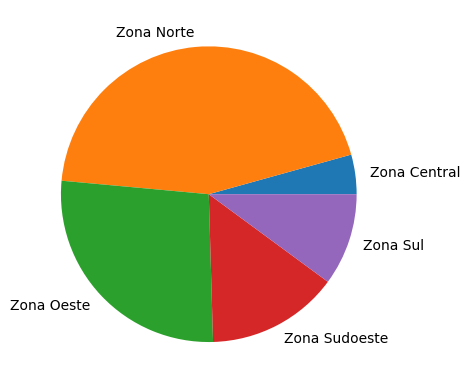

In [24]:
# A proporção em 2022
pop_rio_2022 = df[(df['mes'] == 7) & (df['ano'] == 2022)].groupby(['ano','Zona'], as_index=False).pop.sum()
plt.pie(pop_rio_2022['pop'], labels = pop_rio_2022['Zona'])

## Categorizando crimes
Há dezenas de colunas registrando crimes muito específicos. Sendo assim, nos será muito útil agrupar crimes em categorias, com a contagem somada de suas ocorrências.

Por ora, manteremos os dados mais granulares intactos, e apenas adicionaremos novas colunas com suas somas.

In [25]:
# Grupo: crimes violentos
df['violentos'] = df['hom_doloso'] + df['lesao_corp_morte'] + df['latrocinio'] + df['cvli'] + df['hom_por_interv_policial'] + df['letalidade_violenta'] + df['tentat_hom'] + df['lesao_corp_dolosa'] + df['estupro'] # Feminicido sumiu?

# Grupo: crimes de transito
df['transito'] = df['hom_culposo'] + df['lesao_corp_culposa']

# Grupo: roubos
df['roubos'] = df[['roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_veiculo', 'roubo_carga', 'roubo_comercio', 'roubo_residencia', 'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque', 'roubo_apos_saque', 'roubo_cx_eletronico', 'roubo_bicicleta', 'outros_roubos']].sum(axis=1, skipna=True)
# Já existe uma coluna com o total de roubos, mas vamos primeiro verificar sua veracidade
if (df['roubos'] == df['total_roubos']).all():
    print("A soma dos roubos é igual ao total de roubos.")
else:
    print("A soma dos roubos NÃO é igual ao total de roubos.")
# Por algum motivo a coluna está em formato float, apesar de ser uma contagem de números inteiros. Corrigindo isso:
df['roubos'] = df['roubos'].fillna(0).astype(int)

# Grupo: furtos
# Já existe uma coluna com o total de furtos, mas vamos primeiro verificar sua veracidade
df['furtos'] = df[['furto_veiculos', 'furto_transeunte', 'furto_coletivo', 'furto_celular', 'outros_furtos']].sum(axis=1, skipna=True)
if (df['furtos'] == df['total_furtos']).all():
    print("A soma dos furtos é igual ao total de furtos.")
else:
    print("A soma dos furtos NÃO é igual ao total de furtos.")

# Grupo: outros crimes
df['outros'] = df['sequestro'] + df['extorsao'] + df['sequestro_relampago'] + df['estelionato']

# Não irei considerar atividade policial e outras colunas não referentes a crimes

A soma dos roubos NÃO é igual ao total de roubos.
A soma dos furtos NÃO é igual ao total de furtos.


In [26]:
# Removendo as colunas 'total' que parecem ter somas incorretas
df = df.drop(columns=['total_roubos', 'total_furtos'])

## Valores Faltantes


In [27]:
# Checando onde ainda estão no dataset
df.isna().sum()[df.isna().sum() > 0]

,0
feminicidio,9427
tentativa_feminicidio,9427
roubo_bicicleta,4222
furto_bicicleta,4222
posse_drogas,1080
trafico_drogas,1080
apreensao_drogas_sem_autor,1080
apf,1080
aaapai,1080
cmp,1080


In [28]:
# Feminicidio
df.loc[df['feminicidio'].notna(), ['mes_ano', 'feminicidio']].sort_values(by='mes_ano', ascending=True).head(5)

,mes_ano,feminicidio
9427,2024m10,0.0
9450,2024m10,0.0
9451,2024m10,0.0
9452,2024m10,0.0
9453,2024m10,0.0


In [29]:
# roubo_bicicleta
df.loc[df['roubo_bicicleta'].notna() , ['mes_ano', 'roubo_bicicleta']].sort_values(by='mes_ano', ascending=True).head(5)

,mes_ano,roubo_bicicleta
4222,2014m01,0.0
4244,2014m01,0.0
4245,2014m01,0.0
4246,2014m01,0.0
4247,2014m01,0.0


In [30]:
# furto_bicicleta
df.loc[df['furto_bicicleta'].notna(), ['mes_ano', 'furto_bicicleta']].sort_values(by='mes_ano', ascending=True).head(5)

,mes_ano,furto_bicicleta
4222,2014m01,0.0
4244,2014m01,0.0
4245,2014m01,0.0
4246,2014m01,0.0
4247,2014m01,0.0


In [31]:
# posse_drogas
df.loc[df['posse_drogas'].notna(), ['mes_ano', 'posse_drogas']].sort_values(by='mes_ano', ascending=True).head(5)

,mes_ano,posse_drogas
1080,2006m01,3.0
1109,2006m01,3.0
1108,2006m01,2.0
1107,2006m01,4.0
1106,2006m01,1.0


In [32]:
# posse_drogas - fim do período sem registros
df.loc[df['posse_drogas'].isna(), ['mes_ano', 'posse_drogas']].sort_values(by='mes_ano', ascending=False).head(5)

,mes_ano,posse_drogas
1079,2005m12,NaN
1064,2005m12,NaN
1050,2005m12,NaN
1051,2005m12,NaN
1052,2005m12,NaN


In [33]:
# trafico_drogas
df.loc[df['trafico_drogas'].notna(), ['mes_ano', 'trafico_drogas']].sort_values(by='mes_ano', ascending=True).head(5)

,mes_ano,trafico_drogas
1080,2006m01,0.0
1109,2006m01,0.0
1108,2006m01,1.0
1107,2006m01,5.0
1106,2006m01,1.0


* **feminicidio e tentativa_feminicio** simplesmente não servem para uma série histórica, visto que a contagem começa apenas em 2024
* **roubo_bicicleta e furto_bicicleta** se encontram numa situação similar, começando a serem registrados apenas em 2014
* **posse_drogas e trafico_drogas** demonstram uma contagem significativamente menor de NAs porque só perderam os primeiros anos do dataset, havendo começado os registros em 2006
* **pop** (população), como visto antes, não passa de 2022.

In [34]:
# Deletar colunas
df = df.drop(columns=['feminicidio','tentativa_feminicidio','roubo_bicicleta','furto_bicicleta'])
df.head(5)

,cisp,mes,ano,mes_ano,aisp,risp,mcirc,hom_doloso,lesao_corp_morte,latrocinio,...,fase,Unidade Territorial,Município,Zona,pop,violentos,transito,roubos,furtos,outros
0,1,1,2003,2003m01,5,1,3304557,0,0,0,...,3,Centro (parte),Rio de Janeiro,Zona Central,1551,41,16,100,169,70
1,4,1,2003,2003m01,5,1,3304557,3,0,0,...,3,"Centro (parte), Gamboa, Santo Cristo e Saúde",Rio de Janeiro,Zona Central,29903,57,39,83,115,2
2,5,1,2003,2003m01,5,1,3304557,3,0,0,...,3,"Centro (parte), Lapa e Paquetá",Rio de Janeiro,Zona Central,35792,85,20,123,216,37
3,9,1,2003,2003m01,2,1,3304557,1,1,0,...,3,"Catete, Cosme Velho, Flamengo, Glória e Laranj...",Rio de Janeiro,Zona Sul,129422,53,15,124,268,20
4,10,1,2003,2003m01,2,1,3304557,1,0,0,...,3,"Botafogo, Humaitá e Urca",Rio de Janeiro,Zona Sul,97888,56,26,112,290,19


# Análise de Dados

(WIP) Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset de segurança pública do Rio de Janeiro, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

Visto que este é um dataset complexo, será necessário eventualmente limitar a sua extensa granularidade. Por ora, podemos ainda investigá-lo do jeito que é.

## Total e Tipo das Instâncias

Após passar por nosso preparo preliminar, o dataset possui 10124 instâncias (observações) e 66 colunas - volume considerável. Visto que a a maioria das colunas representam contagens de registros, deveriam ser de tipo integer, mas temos algumas instâncias de floats presentes que devem ser investigadas adiante.

In [ ]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 10124

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10124 entries, 0 to 10123
Data columns (total 66 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        10124 non-null  int64  
 1   mes                         10124 non-null  int64  
 2   ano                         10124 non-null  int64  
 3   mes_ano                     10124 non-null  object 
 4   aisp                        10124 non-null  int64  
 5   risp                        10124 non-null  int64  
 6   mcirc                       10124 non-null  int64  
 7   hom_doloso                  10124 non-null  int64  
 8   lesao_corp_morte            10124 non-null  int64  
 9   latrocinio                  10124 non-null  int64  
 10  cvli                        10124 non-null  int64  
 11  hom_por_interv_policial     10124 non-null  int64  
 12  letalidade_violenta         10124

Devido à extensão do dataset, é impossível retratá-lo num gráfico só sem antes agregar features como tipos de registros ou zonas.

A seguir estudaremos as estatísticas descritivas para depois agregarmos o dataset.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [ ]:
# estatísticas descritivas básicas do dataset
df.describe()

,cisp,mes,ano,aisp,risp,mcirc,hom_doloso,lesao_corp_morte,latrocinio,cvli,...,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,pop,violentos,transito,roubos,furtos,outros
count,10124.000000,10124.000000,10124.000000,10124.000000,10124.000000,10124.0,10124.000000,10124.000000,10124.000000,10124.000000,...,10124.000000,10124.000000,10124.000000,10124.000000,8565.0,10124.000000,10124.000000,10124.000000,10124.000000,10124.000000
mean,23.789609,6.475603,2014.897175,14.391150,1.363493,3304557.0,2.879395,0.043955,0.130383,3.053734,...,0.029040,0.005136,747.123370,2.991900,158895.618564,72.925326,33.379889,162.750395,190.545140,62.124753
std,11.927826,3.467621,6.560593,11.171262,0.481029,0.0,3.746904,0.218533,0.424701,3.852829,...,0.195136,0.074200,362.040823,0.089637,105962.25185,55.843271,26.467657,108.085695,129.771687,68.806648
min,1.000000,1.000000,2003.000000,2.000000,1.000000,3304557.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,2.000000,1551.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,3.000000,2010.000000,5.000000,1.000000,3304557.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,521.000000,3.000000,91030.0,37.000000,16.000000,88.000000,103.000000,20.000000
50%,24.000000,6.000000,2015.000000,14.000000,1.000000,3304557.0,2.000000,0.000000,0.000000,2.000000,...,0.000000,0.000000,679.000000,3.000000,132437.0,57.000000,27.000000,143.000000,162.500000,39.000000
75%,34.000000,9.000000,2021.000000,22.000000,2.000000,3304557.0,4.000000,0.000000,0.000000,4.000000,...,0.000000,0.000000,884.250000,3.000000,195977.0,89.000000,43.000000,210.000000,244.000000,80.000000
max,44.000000,12.000000,2026.000000,41.000000,2.000000,3304557.0,43.000000,3.000000,9.000000,43.000000,...,4.000000,2.000000,3185.000000,3.000000,587400.0,413.000000,268.000000,906.000000,1660.000000,744.000000


### Média e Mediana

A **média** é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

A **mediana** é o valor central que divide um conjunto de dados ordenados (crescente ou decrescente) em duas metades iguais.  É mais robusta a valores extremos (outliers) do que a média, portanto pode dar uma ideia melhor de um valor típico porque não é tão distorcida por valores extremamente altos ou baixos.

Mas média e mediana do que?

É típico no estudo da criminalidade usar as taxas de crimes por 100.000 habitantes; Ex: "Quantos crimes ocorreriam se cada zona tivesse exatamente 100.000 habitantes?"

Utilizando este valor relativo, torna-se possível comparar a criminalidade regiões com populações de tamanhos distintos. Caso contrário, arrisca-se minimizar o crime em locais de baixa densidade populacional e exagerar a significância da contagem em locais com alta densidade populacional.

Fórmula:
   taxa = (total de crimes / população) × 100.000

In [ ]:
# Média das categorias de crimes na cidade como um todo e considerando o período de 23 anos como um todo
#df.groupby('Município')[['violentos','transito','roubos','furtos','outros']].agg(['mean', 'median']).round(2)

In [ ]:
# Média e mediana *mensais* de crimes por unidade territorial, agregando o município como um todo.
# "Num mês típico, numa unidade territorial típica do Rio, quantos crimes por 100 mil habitantes ocorreram em cada categoria?"

crime_cols = ['violentos', 'transito', 'roubos', 'furtos', 'outros']

df_taxa = df.copy()
for col in crime_cols:
    df_taxa[f'{col}_100k'] = (df_taxa[col] / df_taxa['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in crime_cols]

df_taxa.groupby('Município')[cols_100k].agg(['mean', 'median']).round(2)
# WIP Upgrade do código acima

violentos_100k        transito_100k        roubos_100k          \
                         mean median          mean median        mean  median   
Município                                                                       
Rio de Janeiro          86.84  45.02         48.68  20.32      307.87  107.18   

               furtos_100k        outros_100k         
                      mean median        mean median  
Município                                             
Rio de Janeiro      584.43  94.24      208.28  22.32

Antes de partir para a comparação entre zonas e dos diferentes momentos no tempo, temos aqui uma visão agregada das categorias de crimes no Rio de Janeiro. As medidas de média e mediana se referem então à variação das contagens de ocorrências ao longo do período registrado.

Pode ser difícil de contemplar, por conta do quão abstrata esta agregação de dimensões é. Sendo assim, inevitavelmente teremos que investigar os dados de maneira mais granular!

In [ ]:
# Antes disso, um exemplo particular
#
# "Qual a taxa de crimes violentos por 100 mil habitantes
# no CISP 1 (Centro (parte))? Como progride no tempo?"
df_taxa[(df_taxa['cisp'] == 1) & (df_taxa['ano']< 2023)][['cisp','mes_ano','Unidade Territorial','Zona','pop','violentos','violentos_100k']]

,cisp,mes_ano,Unidade Territorial,Zona,pop,violentos,violentos_100k
0,1,2003m01,Centro (parte),Zona Central,1551,41,2643.46
30,1,2003m02,Centro (parte),Zona Central,1551,37,2385.56
60,1,2003m03,Centro (parte),Zona Central,1551,30,1934.24
90,1,2003m04,Centro (parte),Zona Central,1551,25,1611.86
120,1,2003m05,Centro (parte),Zona Central,1551,26,1676.34
...,...,...,...,...,...,...,...
8361,1,2022m08,Centro (parte),Zona Central,1773,9,507.61
8402,1,2022m09,Centro (parte),Zona Central,1773,7,394.81
8443,1,2022m10,Centro (parte),Zona Central,1773,17,958.83
8484,1,2022m11,Centro (parte),Zona Central,1773,18,1015.23


Temos que em janeiro de 2003 a CISP 1 teve uma taxa altíssima de aproximadamente 2643 crimes violentos por 100 mil habitantes. Note que isso ocorre em grande parte por conta de quão depopulada a região é, com apenas 1551 habitantes na época.

Inspecionando qual região exatamente a CISP 1 corresponde a, encontramos que é a região portuária do Rio de Janeiro, uma região antes dedicada ao transporte de bens que caiu em desuso e abandono, com apenas recentes esforços em revitalizá-la como o 'Porto Maravilha'. Esse entendimento parece consistente com os dados!

In [ ]:
# Agrupando por Zona:
#
# Média e mediana dos crimes dentro de uma unidade territorial por zona
#df.groupby('Zona')[['violentos','transito','roubos','furtos','outros']].agg(['mean', 'median']).round(2)

In [ ]:
# Agrupando por Zona:
#
# Média e mediana mensais dos registros de crimes por zona:
crime_cols = ['violentos', 'transito', 'roubos', 'furtos', 'outros']

df_zona = df.copy()
for col in crime_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in crime_cols]

df_zona.groupby('Zona')[cols_100k].agg(['mean', 'median']).round(2)

violentos_100k        transito_100k        roubos_100k          \
                        mean median          mean median        mean  median   
Zona                                                                           
Zona Central           362.6   98.1        233.24  59.98      1586.5  343.65   
Zona Norte             44.97  42.81         20.61  19.14      146.89  134.35   
Zona Oeste             52.69  51.18         20.36  19.44       65.15   59.34   
Zona Sudoeste          47.89  46.42         24.08  21.66       67.95   63.02   
Zona Sul               36.58  34.58         17.82  16.94       80.53   80.86   

              furtos_100k         outros_100k         
                     mean  median        mean median  
Zona                                                  
Zona Central       3581.4  424.89     1372.85  43.92  
Zona Norte         102.32   82.81        24.5  17.54  
Zona Oeste          52.99   50.48       16.38  13.56  
Zona Sudoeste      126.68   97.78       38.38  27.92  
Zona Sul           231.46   224.7       47.85  40.44

Note: estas são a média e mediana do período de 23 anos como um todo! Precisamos de outro tipo de representação gráfica para capturar a tendência no tempo *E* por zona.


Temos um claro padrão de a média das ocorrências ser maior do que a mediana (especialmente na zona central), o que nos leva a um única conclusão:

=> O conjunto de dados é enviesado para a direita!

Isto é, a maioria dos registros são relativamente baixos (em relação à amplitude de sua distribuição), mas há locais e/ou momentos em que as diversas variedades de crimes atingem ***proporções extremas e atípicas*** que puxam a média para cima. Em outras palavras, o crime no Rio de Janeiro está longe de ser invariável nas escalas temporal e espacial, e esta variação parece ocorrer no sentido de ***aumento da criminalidade***, e raramente no sentido de uma redução atípica.

In [ ]:
# Agrupando por ano:
# Média e mediana dos crimes dentro de uma unidade territorial *por ano* na cidade do Rio de Janeiro como um todo
#df.groupby('ano')[['violentos','transito','roubos','furtos','outros']].agg(['mean', 'median']).round(2)

In [ ]:
# Agrupando por ano:
#
# Média e mediana mensais dos crimes dentro de uma unidade territorial *por ano* na cidade do Rio de Janeiro como um todo
# Isto é, a criminalidade num mês típico de cada um dos anos no dataset
crime_cols = ['violentos', 'transito', 'roubos', 'furtos', 'outros']

df_zona = df.copy()
for col in crime_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in crime_cols]

df_zona.groupby('ano')[cols_100k].agg(['mean', 'median']).round(2)

violentos_100k        transito_100k        roubos_100k          \
               mean median          mean median        mean  median   
ano                                                                   
2003         138.88  53.04         74.36  25.16      366.59  134.03   
2004         132.07   51.7          74.3  24.29       319.7  115.62   
2005         113.45  53.04          57.9  22.82      344.98  116.13   
2006         115.99  48.97         63.03  20.51      378.29  132.06   
2007         120.44  47.98         74.02  22.66      488.35  135.23   
2008         110.31   45.0         83.76  25.14      484.32  135.99   
2009          119.7  47.74         59.97   22.9      500.16  121.14   
2010         118.55  48.38         77.99  24.78      375.92   100.1   
2011         111.96  50.39         93.25  26.94      268.18   79.89   
2012         102.41  55.01         76.64  26.35      211.54   72.34   
2013          89.77  53.24         53.36  27.26      240.47   85.24   
2014          76.83  53.25         41.66  26.24      231.46  105.22   
2015          67.06  47.66         35.95  23.52      231.52  100.36   
2016           70.6  45.08         33.75  20.05      270.49  131.88   
2017          64.44   41.7         28.17  16.02      315.14   163.2   
2018           61.0   40.5         28.55  15.36      356.84  157.79   
2019          61.09  38.98         25.88  14.85      326.12  128.36   
2020          43.83  28.66         13.21   9.27      223.61   76.44   
2021          44.35  28.51         15.16    9.8      192.68   76.41   
2022          49.35  32.03         16.11  10.75      216.32   78.16   
2023           <NA>   <NA>          <NA>   <NA>        <NA>    <NA>   
2024           <NA>   <NA>          <NA>   <NA>        <NA>    <NA>   
2025           <NA>   <NA>          <NA>   <NA>        <NA>    <NA>   
2026           <NA>   <NA>          <NA>   <NA>        <NA>    <NA>   

     furtos_100k         outros_100k         
            mean  median        mean median  
ano                                          
2003       573.5   81.03      166.84   9.34  
2004       623.1   81.37       151.5  10.22  
2005       672.0    83.8      174.47  14.17  
2006      752.99   86.36      240.96   13.9  
2007      835.76   99.39      378.41  16.05  
2008      880.61  112.68      265.61  17.33  
2009      889.24  111.56      302.04  14.22  
2010      908.88  109.72      311.22  16.19  
2011      748.59  103.65      268.82  19.27  
2012       683.9   105.1       244.4   21.4  
2013      565.91  103.68      212.58  23.34  
2014      508.59   96.63      126.61  23.35  
2015      471.96   89.48      166.91  23.06  
2016      488.19   91.19      118.92  24.11  
2017      419.82   93.46      130.18  20.02  
2018      442.65   81.31      137.96  22.73  
2019      524.11   91.34       180.6  25.74  
2020      303.87   70.82      194.29  31.62  
2021      262.34   71.04      233.72  44.83  
2022      530.65  100.24      244.44  73.41  
2023        <NA>    <NA>        <NA>   <NA>  
2024        <NA>    <NA>        <NA>   <NA>  
2025        <NA>    <NA>        <NA>   <NA>  
2026        <NA>    <NA>        <NA>   <NA>

Encontraremos mais insights quando olharmos para as visualizações, sem falar que aqui não vamos as diferenças entre zonas, mas mesmo nesta tabela já podemos perceber que:
* Há uma queda dos crimes **violentos**, de **trânsito** e **roubos** no Rio de Janeiro.
* A categoria **furtos** é de longe a mais errática, sem uma clareza de tendência (será melhor compreendida quando criarmos visualizações)
* Há uma ascensão dos **"outros crimes"** - o que nos convida a investigar quais especificamente que puxam esta média.


<br>

---
<br>

Vamos agora tornar nosso olhar ainda mais granular ao investigar os diferentes tipos de crime dentro de cada uma das 5 categorias.

### Crimes Violentos

In [ ]:
# Violentos:
# Por zona, a média e mediana dos crimes violentos
#df.groupby('Zona')[['hom_doloso','lesao_corp_morte','latrocinio','cvli','hom_por_interv_policial','letalidade_violenta','tentat_hom','lesao_corp_dolosa','estupro']].agg(['mean', 'median']).round(2)
# WIP aplicar metodologia "1 em 100.000"

In [ ]:
# Violentos:
#
# Por zona, a média e mediana mensais de cada crimes violento

violentos_cols = ['hom_doloso','lesao_corp_morte','latrocinio','cvli','hom_por_interv_policial','letalidade_violenta','tentat_hom','lesao_corp_dolosa','estupro']

df_zona = df.copy()
for col in violentos_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in violentos_cols]

df_zona.groupby('Zona')[cols_100k].agg(['mean', 'median']).round(2)

hom_doloso_100k        lesao_corp_morte_100k         \
                         mean median                  mean median   
Zona                                                                
Zona Central             6.81   1.26                  0.24    0.0   
Zona Norte               2.13   1.59                  0.03    0.0   
Zona Oeste               2.53   2.01                  0.02    0.0   
Zona Sudoeste             1.3   1.08                  0.01    0.0   
Zona Sul                 0.58    0.0                  0.02    0.0   

              latrocinio_100k        cvli_100k         \
                         mean median      mean median   
Zona                                                    
Zona Central             1.04    0.0       8.1   2.32   
Zona Norte               0.14    0.0       2.3   1.75   
Zona Oeste               0.06    0.0      2.61   2.07   
Zona Sudoeste            0.05    0.0      1.36   1.11   
Zona Sul                 0.04    0.0      0.64    0.0   

              hom_por_interv_policial_100k        letalidade_violenta_100k  \
                                      mean median                     mean   
Zona                                                                         
Zona Central                          1.22    0.0                     9.32   
Zona Norte                            0.95   0.52                     3.25   
Zona Oeste                            0.51   0.23                     3.12   
Zona Sudoeste                         0.21    0.0                     1.56   
Zona Sul                              0.26    0.0                      0.9   

                     tentat_hom_100k        lesao_corp_dolosa_100k         \
              median            mean median                   mean median   
Zona                                                                        
Zona Central    2.53           11.66   3.14                 314.42  74.26   
Zona Norte      2.55             2.4   1.66                  32.24  30.58   
Zona Oeste       2.6            1.71   1.33                  39.38  38.99   
Zona Sudoeste   1.39            1.55   1.12                  39.72  38.13   
Zona Sul         0.0            2.03    0.9                   30.9  29.21   

              estupro_100k         
                      mean median  
Zona                               
Zona Central          9.79   2.43  
Zona Norte            1.54   1.37  
Zona Oeste            2.75   2.51  
Zona Sudoeste         2.14   2.03  
Zona Sul              1.21   1.03

In [ ]:
# Violentos 2:
# Por ano, a média e mediana dos crimes violentos na cidade como um todo
#df.groupby('ano')[['hom_doloso','lesao_corp_morte','latrocinio','cvli','hom_por_interv_policial','letalidade_violenta','tentat_hom','lesao_corp_dolosa','estupro']].agg(['mean', 'median']).round(2)

In [ ]:
# Violentos 2:
#
# Por ano, a média e mediana mensais de cada crimes violento na cidade como um todo

df_zona = df.copy()
for col in violentos_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in violentos_cols]

df_zona.groupby('ano')[cols_100k].agg(['mean', 'median']).round(2)

hom_doloso_100k        lesao_corp_morte_100k        latrocinio_100k  \
                mean median                  mean median            mean   
ano                                                                        
2003            3.39   2.29                  0.04    0.0            0.16   
2004            4.46   2.28                  0.03    0.0            0.55   
2005            3.98   2.25                  0.06    0.0            0.64   
2006            3.47   2.34                  0.05    0.0            0.38   
2007            4.59   2.12                  0.05    0.0            0.66   
2008            3.39   1.71                  0.06    0.0            0.51   
2009            4.49   1.67                  0.02    0.0             0.3   
2010             2.6   1.23                  0.04    0.0             0.1   
2011            2.17   1.08                  0.17    0.0            0.23   
2012             2.1   1.08                  0.03    0.0            0.06   
2013            1.87   1.22                  0.03    0.0             0.2   
2014            1.81    1.1                  0.15    0.0            0.08   
2015            1.62   1.11                  0.03    0.0            0.06   
2016            1.75   1.19                  0.04    0.0            0.25   
2017            2.06   1.52                  0.02    0.0            0.12   
2018            1.89   1.35                  0.05    0.0            0.09   
2019             1.7   1.15                  0.03    0.0            0.17   
2020            1.86   0.86                  0.02    0.0            0.04   
2021            0.91   0.71                  0.14    0.0            0.16   
2022            1.18   0.72                  0.01    0.0            0.05   
2023            <NA>   <NA>                  <NA>   <NA>            <NA>   
2024            <NA>   <NA>                  <NA>   <NA>            <NA>   
2025            <NA>   <NA>                  <NA>   <NA>            <NA>   
2026            <NA>   <NA>                  <NA>   <NA>            <NA>   

            cvli_100k        hom_por_interv_policial_100k         \
     median      mean median                         mean median   
ano                                                                
2003    0.0      3.59   2.43                         1.05   0.49   
2004    0.0      5.04   2.55                         1.11   0.26   
2005    0.0      4.68   2.59                         1.23   0.43   
2006    0.0      3.89   2.51                         0.94   0.42   
2007    0.0       5.3    2.3                          1.8   0.73   
2008    0.0      3.95   2.09                         0.93   0.12   
2009    0.0      4.81   1.95                         1.27   0.26   
2010    0.0      2.73    1.4                         0.55    0.0   
2011    0.0      2.57   1.17                         0.35    0.0   
2012    0.0      2.19   1.21                         0.35    0.0   
2013    0.0       2.1   1.35                         0.28    0.0   
2014    0.0      2.04   1.14                         0.31    0.0   
2015    0.0      1.71   1.19                          0.4    0.0   
2016    0.0      2.03   1.24                         0.72    0.0   
2017    0.0       2.2    1.6                         0.75    0.0   
2018    0.0      2.03   1.38                         0.73    0.0   
2019    0.0      1.89   1.19                         0.91    0.0   
2020    0.0      1.92   0.88                         0.48    0.0   
2021    0.0      1.21   0.75                         0.57    0.0   
2022    0.0      1.24    0.8                         0.49    0.0   
2023   <NA>      <NA>   <NA>                         <NA>   <NA>   
2024   <NA>      <NA>   <NA>                         <NA>   <NA>   
2025   <NA>      <NA>   <NA>                         <NA>   <NA>   
2026   <NA>      <NA>   <NA>                         <NA>   <NA>   

     letalidade_violenta_100k        tentat_hom_100k         \
                         mean median            mean

Por zona:
* Homicídio doloso e crimes violentos letais intencionais (cvli) demonstram significante variabilidade entre zonas, com a maior diferença sendo entre a Zona Central (max) e Zona Sul (min).
* Lesão corporal dolosa, sendo um crime muito mais frequente, acompanha o padrão regional dos homicídios.

Por ano:
* Homicídio doloso - assim como a maioria dos outros crimes violentos - possui uma média e mediana relativamente baixa quando contrastadas aos outros crimes deste dataset. Sem grandes picos ou quedas.
* Lesão corporal dolosa, isto é, o crime de ferir o outro, é distintamente mais frequente que todos os outros juntos. Enquanto sua média despencou, sua mediana foi reduzida de maneira mais moderada, indicando uma queda dos valores extremamente altos.



### Crimes de Trânsito

In [ ]:
# Crimes de Trânsito
# df['hom_culposo'] + df['lesao_corp_culposa']
#df.groupby('ano')[['hom_culposo','lesao_corp_culposa']].mean().round(2)

In [ ]:
# Crimes de Trânsito:
#
# Por zona, a média e mediana mensais de cada crime de trânsito

transito_cols = ['hom_culposo','lesao_corp_culposa']

df_zona = df.copy()
for col in transito_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in transito_cols]

df_zona.groupby('Zona')[cols_100k].agg(['mean', 'median']).round(2)

hom_culposo_100k        lesao_corp_culposa_100k       
                          mean median                    mean median
Zona                                                                
Zona Central              6.17   1.16                  227.07   59.1
Zona Norte                 0.8   0.61                   19.81  18.19
Zona Oeste                0.95   0.81                   19.41  18.69
Zona Sudoeste             0.84    0.7                   23.24  21.04
Zona Sul                  0.62    0.0                    17.2   16.2

In [ ]:
# Crimes de Trânsito 2:
#
# Por ano, a média e mediana mensais de cada crime de trânsito

transito_cols = ['hom_culposo','lesao_corp_culposa']

df_zona = df.copy()
for col in transito_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in transito_cols]

df_zona.groupby('ano')[cols_100k].agg(['mean', 'median']).round(2)

hom_culposo_100k        lesao_corp_culposa_100k       
                 mean median                    mean median
ano                                                        
2003             2.29   0.82                   72.07  23.84
2004             2.84   0.88                   71.46  23.82
2005             2.21   0.99                    55.7  21.87
2006             2.03   0.86                   61.01  19.47
2007             2.16    1.0                   71.87  21.45
2008             2.08   0.86                   81.68  24.21
2009             1.28   0.55                   58.69  22.12
2010             1.79    0.7                    76.2  23.85
2011             2.12   0.71                   91.13  26.15
2012             1.61   0.63                   75.03  25.69
2013             0.96   0.56                    52.4  26.66
2014             0.76   0.56                    40.9  25.64
2015             0.82    0.0                   35.13  22.77
2016             1.03   0.36                   32.71  19.62
2017             1.27   0.55                    26.9  15.22
2018             1.31   0.59                   27.24   14.7
2019             1.35   0.53                   24.53  14.02
2020             0.86   0.52                   12.35   8.56
2021              1.5   0.44                   13.66   9.14
2022             0.99   0.49                   15.12  10.11
2023             <NA>   <NA>                    <NA>   <NA>
2024             <NA>   <NA>                    <NA>   <NA>
2025             <NA>   <NA>                    <NA>   <NA>
2026             <NA>   <NA>                    <NA>   <NA>

Por zona:
* Os valores da Zona Central são significativamente maiores que os das outras zonas, além de apresentarem diferença considerável entre média e mediana, o que insinua a presença de outliers.
* Zonas Oeste e Sudoeste em distantes segundo e terceiro lugar em frequência de crimes violentos.

Por ano:
* Homicídio culposo apresenta queda gradual ao longo do período.
* Lesão corporal culposa teve um pico prolongado no meio do período, em meados de 2012, mas esteve em baixa desde antes da pandemia (sem os dados populacionais de 2023 a 2026 é difícil avaliar o que é o novo normal e o que é efeito da pandemia nesses últimos anos)



### Roubos

In [ ]:
# Roubos
#f[['roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_rua', 'roubo_veiculo', 'roubo_carga', 'roubo_comercio', 'roubo_residencia', 'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque', 'roubo_apos_saque', 'roubo_cx_eletronico', 'roubo_bicicleta', 'outros_roubos']].sum(axis=1, skipna=True)
#df.groupby('ano')[['roubo_transeunte','roubo_celular','roubo_em_coletivo','roubo_rua','roubo_veiculo','roubo_carga','roubo_comercio','roubo_residencia','roubo_banco','roubo_cx_eletronico','roubo_conducao_saque','roubo_apos_saque','roubo_cx_eletronico','outros_roubos']].mean().round(2)

In [ ]:
# Roubos:
#
# Por zona, a média e mediana mensais de cada tipo de roubo

roubo_cols = ['roubo_transeunte','roubo_celular','roubo_em_coletivo','roubo_veiculo','roubo_carga','roubo_comercio','roubo_residencia','roubo_banco','roubo_cx_eletronico','roubo_conducao_saque','roubo_apos_saque','roubo_cx_eletronico','outros_roubos']

df_zona = df.copy()
for col in roubo_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in roubo_cols]

df_zona.groupby('Zona')[cols_100k].agg(['mean', 'median']).round(2)

roubo_transeunte_100k         roubo_celular_100k         \
                               mean  median               mean median   
Zona                                                                    
Zona Central                  878.6  140.46              220.8  29.76   
Zona Norte                    55.98   49.83              13.27  10.03   
Zona Oeste                    26.41   20.84               6.22   4.39   
Zona Sudoeste                 27.45   25.64               7.22   6.34   
Zona Sul                      35.97   33.09               9.72   8.06   

              roubo_em_coletivo_100k        roubo_veiculo_100k         \
                                mean median               mean median   
Zona                                                                    
Zona Central                    99.0   26.9              46.83  22.22   
Zona Norte                      8.92   6.19              35.92  30.76   
Zona Oeste                      3.62   3.22              16.54  13.52   
Zona Sudoeste                   4.82   3.97              12.63   9.62   
Zona Sul                         4.7   3.84               5.47   3.29   

              roubo_carga_100k         ... roubo_cx_eletronico_100k         \
                          mean median  ...                     mean median   
Zona                                   ...                                   
Zona Central             46.65   4.62  ...                     1.75    0.0   
Zona Norte                5.61   3.57  ...                     0.04    0.0   
Zona Oeste                2.71   2.03  ...                     0.02    0.0   
Zona Sudoeste             0.97   0.72  ...                     0.03    0.0   
Zona Sul                  0.58    0.0  ...                     0.04    0.0   

              roubo_conducao_saque_100k        roubo_apos_saque_100k         \
                                   mean median                  mean median   
Zona                                                                          
Zona Central                       5.62    0.0                 66.88   2.99   
Zona Norte                         0.11    0.0                  1.36   0.88   
Zona Oeste                         0.04    0.0                  0.74   0.51   
Zona Sudoeste                      0.18    0.0                  1.21   0.73   
Zona Sul                           0.12    0.0                  0.87    0.0   

              roubo_cx_eletronico_100k        outros_roubos_100k         
                                  mean median               mean median  
Zona                                                                     
Zona Central                      1.75    0.0             149.77  44.76  
Zona Norte                        0.04    0.0              20.65  15.08  
Zona Oeste                        0.02    0.0               6.36   4.78  
Zona Sudoeste                     0.03    0.0               9.36    8.3  
Zona Sul                          0.04    0.0              17.06  13.46  

[5 rows x 26 columns]

In [ ]:
# Roubos 2
#
# Por ano, a média e mediana mensais de cada crime de trânsito

df_zona = df.copy()
for col in roubo_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in roubo_cols]

df_zona.groupby('ano')[cols_100k].agg(['mean', 'median']).round(2)

roubo_transeunte_100k        roubo_celular_100k         \
                      mean median               mean median   
ano                                                           
2003                 88.19  17.02              77.67  14.18   
2004                 96.38  20.29              60.15   10.3   
2005                134.39  36.34              38.93   6.44   
2006                165.33  47.67              45.03   7.93   
2007                238.71   58.8              63.49   6.94   
2008                260.28   62.5               65.6   7.38   
2009                325.82  58.76              42.97    7.7   
2010                225.01  48.13               30.0   7.09   
2011                 157.7  38.43              17.73   4.26   
2012                120.56  33.34              13.91   2.82   
2013                138.07   38.7              19.77    3.8   
2014                133.92  54.04              17.79   5.76   
2015                122.78  47.34              24.07   8.58   
2016                133.76   56.0              31.38  11.38   
2017                143.92  57.95              43.77  17.24   
2018                175.26   54.2              52.98  18.77   
2019                163.65  49.25              53.51  17.24   
2020                 122.8  28.26              34.66   9.99   
2021                101.21  29.94              29.73  10.54   
2022                 122.8  27.38              33.38  12.55   
2023                  <NA>   <NA>               <NA>   <NA>   
2024                  <NA>   <NA>               <NA>   <NA>   
2025                  <NA>   <NA>               <NA>   <NA>   
2026                  <NA>   <NA>               <NA>   <NA>   

     roubo_em_coletivo_100k        roubo_veiculo_100k        roubo_carga_100k  \
                       mean median               mean median             mean   
ano                                                                             
2003                  15.89   4.35              47.98  33.92            11.89   
2004                  11.92   4.38               44.8   37.2            10.06   
2005                  20.61   6.42               41.0  34.77             11.8   
2006                  26.27   7.67              43.44   40.3            17.42   
2007                  25.89   7.38              41.36  30.72            25.28   
2008                  27.08    7.3              32.69  25.79            12.05   
2009                  26.41   6.23              27.55  20.96             9.88   
2010                  23.89   5.75              18.15  15.81            21.14   
2011                  17.34   3.85               16.9  12.12             7.82   
2012                   10.6   2.84              16.72  11.73             5.65   
2013                  13.03   3.31              17.28  12.78             5.65   
2014                  12.78   4.34              19.08  12.06             10.8   
2015                  12.62   4.24              20.94  12.64             9.34   
2016                  18.38    6.1              29.03  20.01            10.59   
2017                  20.37   7.67              35.85  28.42             8.91   
2018                  23.03   7.22              35.23   24.7              5.6   
2019                  34.19   7.38              23.46  17.42             5.04   
2020                  16.38    4.1              14.92   11.4             3.02   
2021                  18.25   5.03              14.97  11.77             2.23   
2022                  10.96    3.5              18.34  14.63             3.18   
2023                   <NA>   <NA>               <NA>   <NA>             <NA>   
2024                   <NA>   <NA>               <NA>   <NA>             <NA>   
2025                   <NA>   <NA>               <NA>   <NA>             <NA>   
2026                   <NA>   <NA>               <NA>   <NA>             <NA>   

             ... roubo_cx_eletronico_100k        roubo_conducao_saque_100k  \
     median  ...                     

Por zona:
* Zona Central em evidente destaque parece ser um padrão duradouro neste dataset a este ponto.
* Em 'roubos de rua', contra indivíduos, o padrão dos segundo e terceiro lugares parece divergir do que foi visto na categoria de crimes violentos: agora temos a Zona Norte em segundo lugar e em terceiro, curiosamente, a Zona Sul, que havia ficado em último lugar na categoria anterior.
* Já em crimes de roubo de veículos e carga a Zona Oeste toma o terceiro lugar e a Zona Sul retorna ao último. Essa dinâmica já parece pintar uma perspectiva sobre a incidência dos diferentes crimes no espaço da cidade.

Por ano:
* Roubo de transeuntes (ou assalto) parece ter tido picos em 2008 e 2017, mas estar em baixa atualmente no período pós-pandemico.
* Roubo de celular estranhamente não coincide com o nível de ocorrências do roubo de transeuntes, em geral tendo frequência bem mais baixa. Dito isso, seus picos coicidem com os do tipo anterior. Atualmente estão bem mais próximos do que na maior parte do período.
* Roubo em coletivo (ou arrastão) é mais estável, terminando numa taxa não muito diferente de quando começou, mas compartilha os picos e vales ao longo do caminho com os dois últimos tipos.
* Roubo de veículo tem seu auge nos primeiros anos do dataset, apenas com um outro pico em 2016-2018. Parece estar relativamente em baixa atualmente.
* "Outros roubos" teve uma queda considerável ao longo do período.




### Furtos

In [ ]:
# Furtos:
# A média dos furtos, por ano, na cidade como um todo
#df.groupby('ano')[['furto_veiculos','furto_transeunte','furto_coletivo','furto_celular','outros_furtos']].mean().round(2)

In [ ]:
# Furtos:
#
# Por zona, a média e mediana mensais de cada tipo de furto

furto_cols = ['furto_veiculos','furto_transeunte','furto_coletivo','furto_celular','outros_furtos']

df_zona = df.copy()
for col in furto_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in furto_cols]

df_zona.groupby('Zona')[cols_100k].agg(['mean', 'median']).round(2)

furto_veiculos_100k        furto_transeunte_100k          \
                             mean median                  mean  median   
Zona                                                                     
Zona Central                109.2  16.34               1174.14  107.01   
Zona Norte                  11.97   9.81                 15.84   10.14   
Zona Oeste                   8.34   7.54                  7.08    6.02   
Zona Sudoeste               13.37  10.24                 12.01     9.5   
Zona Sul                    11.78   7.32                 52.69    37.7   

              furto_coletivo_100k        furto_celular_100k         \
                             mean median               mean median   
Zona                                                                 
Zona Central               167.43  28.48              659.3  64.36   
Zona Norte                   6.14   4.92              12.54    8.7   
Zona Oeste                   3.77   3.65               6.51   6.06   
Zona Sudoeste                9.54   7.66              20.71  13.62   
Zona Sul                     15.8  14.09              33.27  28.59   

              outros_furtos_100k          
                            mean  median  
Zona                                      
Zona Central             1471.33  184.54  
Zona Norte                 55.84   46.26  
Zona Oeste                 27.29   26.62  
Zona Sudoeste              71.05   56.07  
Zona Sul                  117.93  110.28

Plea primeira vez zona central não se destaca demais
Segundo lugar zona sudoeste, terceiro zona norte (veiuclos)
Em todos os outro é prata pra zona sul, e de longe!

In [ ]:
# Furtos 2:
#
# Por ano, a média e mediana mensais de cada tipo de furto na cidade

df_zona = df.copy()
for col in furto_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in furto_cols]

df_zona.groupby('ano')[cols_100k].agg(['mean', 'median']).round(2)

furto_veiculos_100k        furto_transeunte_100k         \
                    mean median                  mean median   
ano                                                            
2003               49.67  17.36                112.65   5.94   
2004               56.63   15.4                137.75    5.4   
2005               55.65  14.91                126.92   8.19   
2006               37.43   15.8                 163.6  10.78   
2007               30.69  13.65                221.54  14.48   
2008               45.31   14.1                203.65  17.62   
2009               45.68  12.44                328.98  17.28   
2010                33.2  10.05                331.68  16.18   
2011               22.38   7.19                295.31  17.08   
2012               19.13   8.75                264.93  17.27   
2013               15.67   8.74                201.84   19.2   
2014               13.79   8.66                201.41  17.34   
2015               12.68   8.41                 174.2  16.56   
2016               12.36   7.92                171.32  13.04   
2017               12.79   7.76                 98.83  10.64   
2018               12.83   8.19                121.35  10.23   
2019                13.0   7.18                140.54    9.1   
2020               14.55   6.51                 72.07   4.73   
2021               10.65   7.21                 54.19   5.72   
2022               16.15   8.78                157.58   8.62   
2023                <NA>   <NA>                  <NA>   <NA>   
2024                <NA>   <NA>                  <NA>   <NA>   
2025                <NA>   <NA>                  <NA>   <NA>   
2026                <NA>   <NA>                  <NA>   <NA>   

     furto_coletivo_100k        furto_celular_100k        outros_furtos_100k  \
                    mean median               mean median               mean   
ano                                                                            
2003                1.83    0.0             100.86   5.24             308.49   
2004                 9.1   1.18             120.01   7.66             299.62   
2005               18.52   4.24             144.66   10.8             326.25   
2006                22.6   5.08             179.09  14.96             350.27   
2007               34.24    6.8             176.72  13.53             372.57   
2008                38.2   7.58             177.73  16.45             415.72   
2009               44.77    8.6             129.37  18.27             340.45   
2010               53.66   9.44             152.58  18.55             337.77   
2011               48.06   7.54             113.78  16.32             269.06   
2012               40.23   7.44              87.54  12.64             272.06   
2013               34.18    7.6              79.82  11.12             234.41   
2014               32.35   7.86              58.16   9.66             202.88   
2015               31.34   7.28              72.08   10.1             181.65   
2016               28.96   7.48              76.11   9.61             199.44   
2017               24.65   5.59               62.1   9.14             221.45   
2018                31.3   7.34              72.22   8.08             204.95   
2019               30.07   7.84              86.83   9.62             253.67   
2020               14.33   3.12              59.93   5.63             142.99   
2021               18.66   4.88              45.81   8.09             133.04   
2022               31.04   7.95             140.65  15.92             185.24   
2023                <NA>   <NA>               <NA>   <NA>               <NA>   
2024                <NA>   <NA>               <NA>   <NA>               <NA>   
2025                <NA>   <NA>               <NA>   <NA>               <NA>   
2026                <NA>   <NA>               <NA>   <NA>               <NA>   

             
     median  
ano          
2003  49.19  
2004  49.04  
2005  46.04  
2006  40.18  
2007  49.58  
200

Por zona:
* O destaque da criminalidade na Zona Central é mantido mas muito reduzido.
* Com a excessão do furto de veículos, a Zona Sul é o claro segundo lugar em frequência de ocorrências de todos os outros tipos de furto. Haveria um 'perfil de crime' para a Zona Sul que é distinto do resto da cidade?

Por ano:
* **Furto de veículos** quase cai pela metade ao longo do período
* **Furto de transeuntes** não é muito diferente em 2022 quando comparado a 2003, mas quase todos os anos antes da pandemia permaneceu em um patamar elevado, atingindo seu máximo de 17,62 furtos mensais por 100 mil habitantes em 2008. Sua média é consideravelmente mais alta que a mediana, sugerindo outliers extremos.
* **Furto em coletivo** parece surgir em meados de 2005 e flutua por volta de 7,5 por 100 mil.
* **Furto de celular** acompanha o furto de transeuntes.
* **Outros furtos** (que não se encaixam nas categorias acima) tiveram um ligeiro aumento. Vale notar que sempre foram significantes comparados aos outros



### Outros Crimes Contra o Patrimônio

In [ ]:
# Outros crimes:
# A média dos crimes categorizados como "outros crimes", por ano, na cidade como um todo
df.groupby('ano')[['sequestro','extorsao','sequestro_relampago','estelionato']].mean().round(2)

,sequestro,extorsao,sequestro_relampago,estelionato
ano,,,,
2003,0.01,1.11,0.02,15.22
2004,0.01,1.70,0.04,17.40
2005,0.01,2.78,0.19,20.73
2006,0.01,2.86,0.13,24.81
2007,0.01,1.42,0.05,31.26
2008,0.01,2.25,0.07,30.96
2009,0.01,1.43,0.14,28.46
2010,0.01,1.71,0.12,31.52
2011,0.01,2.19,0.20,37.06


In [ ]:
# Outros crimes:
#
# Por zona, a média e mediana mensais de cada um dos crimes classificados como 'outros crimes contra o patrimônio'
# "Extorsão mediante sequestro (sequestro clássico), Extorsão, Extorsão com momentânea privação da liberdade (sequestro relâmpago), Estelionato"

outros_cols = ['sequestro','extorsao','sequestro_relampago','estelionato']

df_zona = df.copy()
for col in outros_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in outros_cols]

df_zona.groupby('Zona')[cols_100k].agg(['mean', 'median']).round(2)

sequestro_100k        extorsao_100k         \
                        mean median          mean median   
Zona                                                       
Zona Central             0.0    0.0         32.39   2.31   
Zona Norte               0.0    0.0          1.03   0.78   
Zona Oeste               0.0    0.0          0.62   0.52   
Zona Sudoeste            0.0    0.0           1.6   1.37   
Zona Sul                0.01    0.0          2.35   1.52   

              sequestro_relampago_100k        estelionato_100k         
                                  mean median             mean median  
Zona                                                                   
Zona Central                      0.72    0.0          1339.73  42.34  
Zona Norte                        0.09    0.0            23.37  16.56  
Zona Oeste                        0.03    0.0            15.72   12.8  
Zona Sudoeste                     0.18    0.0             36.6  26.28  
Zona Sul                           0.1    0.0            45.38  37.26

In [ ]:
# Outros crimes 2:
#
# Por ano, a média e mediana mensais de cada um dos crimes classificados como 'outros crimes contra o patrimônio'

df_zona = df.copy()
for col in outros_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in outros_cols]

df_zona.groupby('ano')[cols_100k].agg(['mean', 'median']).round(2)

sequestro_100k        extorsao_100k        sequestro_relampago_100k  \
               mean median          mean median                     mean   
ano                                                                        
2003           0.01    0.0           2.9    0.4                     0.01   
2004           0.01    0.0           3.4   0.87                     0.03   
2005            0.0    0.0         10.23   1.42                     0.36   
2006           0.01    0.0          8.94   1.12                     0.11   
2007            0.0    0.0          9.57   0.75                      0.2   
2008           0.01    0.0           8.6   1.19                     0.06   
2009            0.0    0.0          8.36   0.71                     0.08   
2010           0.01    0.0         12.82   0.82                     0.57   
2011            0.0    0.0         11.42   1.13                     0.26   
2012           0.01    0.0           7.1   0.89                     0.14   
2013            0.0    0.0          4.42   1.12                      0.1   
2014            0.0    0.0          2.66   0.94                     0.17   
2015            0.0    0.0          4.18    1.1                     0.11   
2016           0.02    0.0          1.93   0.82                     0.07   
2017            0.0    0.0           4.6   0.91                     0.12   
2018            0.0    0.0           3.0   0.89                     0.21   
2019            0.0    0.0          3.06    0.9                     0.23   
2020            0.0    0.0           1.7    0.6                      0.2   
2021            0.0    0.0          2.14   0.86                     0.17   
2022            0.0    0.0          4.01   1.33                     0.38   
2023           <NA>   <NA>          <NA>   <NA>                     <NA>   
2024           <NA>   <NA>          <NA>   <NA>                     <NA>   
2025           <NA>   <NA>          <NA>   <NA>                     <NA>   
2026           <NA>   <NA>          <NA>   <NA>                     <NA>   

            estelionato_100k         
     median             mean median  
ano                                  
2003    0.0           163.92   8.41  
2004    0.0           148.06   9.12  
2005    0.0           163.87   11.6  
2006    0.0            231.9  11.97  
2007    0.0           368.63   15.0  
2008    0.0           256.93  15.73  
2009    0.0            293.6  13.28  
2010    0.0           297.82  15.17  
2011    0.0           257.13  17.66  
2012    0.0           237.15   20.5  
2013    0.0           208.06  22.33  
2014    0.0           123.79  21.92  
2015    0.0           162.62  21.25  
2016    0.0            116.9  23.22  
2017    0.0           125.46  19.11  
2018    0.0           134.75  21.94  
2019    0.0           177.31  24.44  
2020    0.0            192.4  30.39  
2021    0.0           231.41  43.83  
2022    0.0           240.05   72.0  
2023   <NA>             <NA>   <NA>  
2024   <NA>             <NA>   <NA>  
2025   <NA>             <NA>   <NA>  
2026   <NA>             <NA>   <NA>

Por zona:
* Novamente temos o padrão em que a Zona Sul e Sudoeste, as zonas mais ricas da cidade, ficam em segundo e terceiro lugar.

Por ano:
* Não podia ser mais claro: a categoria "outros crimes" cresceu quase que exclusivamente pro conta da ascensão do **estelionato**, o crime de "obter para si ou para outrem vantagem ilícita em prejuízo alheio, induzindo ou mantendo alguém em erro, mediante artifício, ardil ou qualquer outro meio fraudulento."



In [ ]:
# Qual gráfico seria interessante usar pra mostrar a média?

## Gráfico de Linhas

"O crime no Rio de Janeiro proliferou acima do crescimento populacional? Onde? Em quais categorias?"

Para responder esta hipótese, temos que agregar todos os crimes, a fim de focar nas dimensões de tempo e espaço geográfico.

In [ ]:
crimes_zona_ano = (
    df.groupby(['ano', 'Zona'])[['violentos','transito','roubos','furtos','outros']]
    .sum()
    .sum(axis=1)      # Após somar todos os crimes de uma categoria, soma todas as categorias juntas
    .reset_index()
    .rename(columns={0: 'total_crimes'})
)
print(crimes_zona_ano)

      ano           Zona  total_crimes
0    2003   Zona Central         14657
1    2003     Zona Norte         82032
2    2003     Zona Oeste         20615
3    2003  Zona Sudoeste         17805
4    2003       Zona Sul         26892
..    ...            ...           ...
115  2026   Zona Central          7705
116  2026     Zona Norte         18075
117  2026     Zona Oeste          6819
118  2026  Zona Sudoeste          8125
119  2026       Zona Sul          8478

[120 rows x 3 columns]


In [ ]:
# Recalculando o dataframe pop_rio que criei na seção 'População' deste notebook
# pop_rio = df[(df['mes'] == 7) & (df['ano'] <= 2022)].groupby(['ano','Zona'], as_index=False).pop.sum()
pop_zona_ano = (
    df[(df['mes'] == 7) & (df['ano'] <= 2022)]     # Mês de julho apenas para não contarmos a população anual 12 vezes
    .groupby(['ano', 'Zona'], as_index=False)['pop']
    .sum()
)
print(pop_zona_ano)

     ano           Zona      pop
0   2003   Zona Central   107598
1   2003     Zona Norte  2081171
2   2003     Zona Oeste   932072
3   2003  Zona Sudoeste   774217
4   2003       Zona Sul   604995
..   ...            ...      ...
95  2022   Zona Central   295708
96  2022     Zona Norte  3029038
97  2022     Zona Oeste  1843408
98  2022  Zona Sudoeste   989262
99  2022       Zona Sul   691387

[100 rows x 3 columns]




---



In [ ]:
# Exemplo
# População da Zona Central por ano
print(pop_zona_ano[pop_zona_ano['Zona'] == 'Zona Central'])

# Salto surpreendente em 2011... Note que o censo de 2010 teria atualizado as estimativas de população na época

     ano          Zona     pop
0   2003  Zona Central  107598
5   2004  Zona Central  108419
10  2005  Zona Central  109246
15  2006  Zona Central  110080
20  2007  Zona Central  110919
25  2008  Zona Central  111766
30  2009  Zona Central  112618
35  2010  Zona Central  113477
40  2011  Zona Central  274428
45  2012  Zona Central  275910
50  2013  Zona Central  277623
55  2014  Zona Central  278648
60  2015  Zona Central  279638
65  2016  Zona Central  280597
70  2017  Zona Central  281523
75  2018  Zona Central  288949
80  2019  Zona Central  290717
85  2020  Zona Central  292421
90  2021  Zona Central  294057
95  2022  Zona Central  295708


In [ ]:
# População total por ano
print(pop_zona_ano.groupby('ano').pop.sum())
# Parece que em geral houve uma correção dos dados populacionais em 2010-2011. Melhor desconsiderar explicações socioeconômicas!

ano
2003    4500053
2004    4534380
2005    4568972
2006    4603828
2007    4638947
2008    4674340
2009    4710000
2010    4745929
2011    6114662
2012    6147695
2013    6185825
2014    6138079
2015    6159907
2016    6181030
2017    6448937
2018    6619043
2019    6733197
2020    6772684
2021    6810572
2022    6848803
Name: pop, dtype: Int64




---



In [ ]:
# Cruzando ambos os dataframes sumarizados
df_merged = crimes_zona_ano.merge(pop_zona_ano, on=['ano', 'Zona'], how='left')
df_com_pop = df_merged[df_merged['pop'].notna()].copy() # Filtra anos com dados populacionais (≤ 2022) para as métricas normalizadas
print(df_com_pop)

     ano           Zona  total_crimes      pop
0   2003   Zona Central         14657   107598
1   2003     Zona Norte         82032  2081171
2   2003     Zona Oeste         20615   932072
3   2003  Zona Sudoeste         17805   774217
4   2003       Zona Sul         26892   604995
..   ...            ...           ...      ...
95  2022   Zona Central         34119   295708
96  2022     Zona Norte        109771  3029038
97  2022     Zona Oeste         40396  1843408
98  2022  Zona Sudoeste         46338   989262
99  2022       Zona Sul         39375   691387

[100 rows x 4 columns]


In [ ]:
# Normalizando
# O padrão típico é avaliar o crime per capita no modelo "X ocorrências por 100 mil habitantes"
# Vamos criar novos índices para isso

ano_base = 2003

# WIP EXECUTAR UMA VEZ SÓ


# Índice base 100 no primeiro ano disponível (2003)
base_crimes = (
    df_com_pop[df_com_pop['ano'] == ano_base][['Zona', 'total_crimes']]
    .rename(columns={'total_crimes': 'base_crimes'})
)
base_pop = (
    df_com_pop[df_com_pop['ano'] == ano_base][['Zona', 'pop']]
    .rename(columns={'pop': 'base_pop'})
)

df_com_pop = df_com_pop.merge(base_crimes, on='Zona').merge(base_pop, on='Zona')
df_com_pop['indice_crimes'] = df_com_pop['total_crimes'] / df_com_pop['base_crimes'] * 100
df_com_pop['indice_pop']    = df_com_pop['pop']          / df_com_pop['base_pop']    * 100



---



In [ ]:
# Exemplo:
# Índices de crime e de população no ano de 2022 para a Zona Norte apenas
print(df_com_pop[(df_com_pop['ano'] == 2022) & (df_com_pop['Zona'] == 'Zona Norte')].loc[:,['ano','Zona','indice_crimes','indice_pop']])

# Temos então que o crime cresceu *abaixo* da população da Zona Norte no período registrado!

     ano        Zona  indice_crimes  indice_pop
96  2022  Zona Norte     133.814853  145.544888


In [ ]:
# Exemplo 2:
# Índices de crime e de população ao longo dos anos para a Zona Central apenas
print(df_com_pop[df_com_pop['Zona'] == 'Zona Central'].loc[:,['ano','Zona','indice_crimes','indice_pop']])

# É estranho que a população teria estagnado tanto, apenas para disparar em 2011...

     ano          Zona  indice_crimes  indice_pop
0   2003  Zona Central     100.000000       100.0
5   2004  Zona Central     100.163744  100.763025
10  2005  Zona Central     103.691069  101.531627
15  2006  Zona Central     110.534216  102.306734
20  2007  Zona Central     134.031521  103.086489
25  2008  Zona Central     134.024698  103.873678
30  2009  Zona Central     142.709968  104.665514
35  2010  Zona Central     138.848332  105.463856
40  2011  Zona Central     186.607082   255.04935
45  2012  Zona Central     238.902913  256.426699
50  2013  Zona Central     248.058948  258.018736
55  2014  Zona Central     249.703213  258.971356
60  2015  Zona Central     238.814218  259.891448
65  2016  Zona Central     248.795797  260.782728
70  2017  Zona Central     216.770144  261.643339
75  2018  Zona Central     230.872621  268.544954
80  2019  Zona Central     212.819813  270.188108
85  2020  Zona Central     143.590093   271.77178
90  2021  Zona Central     147.922494  273.292255




---



### Índice Agregado de Crimes por Zona 2003-2022

In [ ]:
# Primeiramente, uma simples tabela
print(df_com_pop.loc[df_com_pop['ano'] == 2022, ['ano', 'Zona', 'indice_crimes', 'indice_pop']])

     ano           Zona  indice_crimes  indice_pop
95  2022   Zona Central     232.782971   274.82667
96  2022     Zona Norte     133.814853  145.544888
97  2022     Zona Oeste     195.954402  197.775279
98  2022  Zona Sudoeste     260.252738  127.775804
99  2022       Zona Sul     146.419009  114.279787


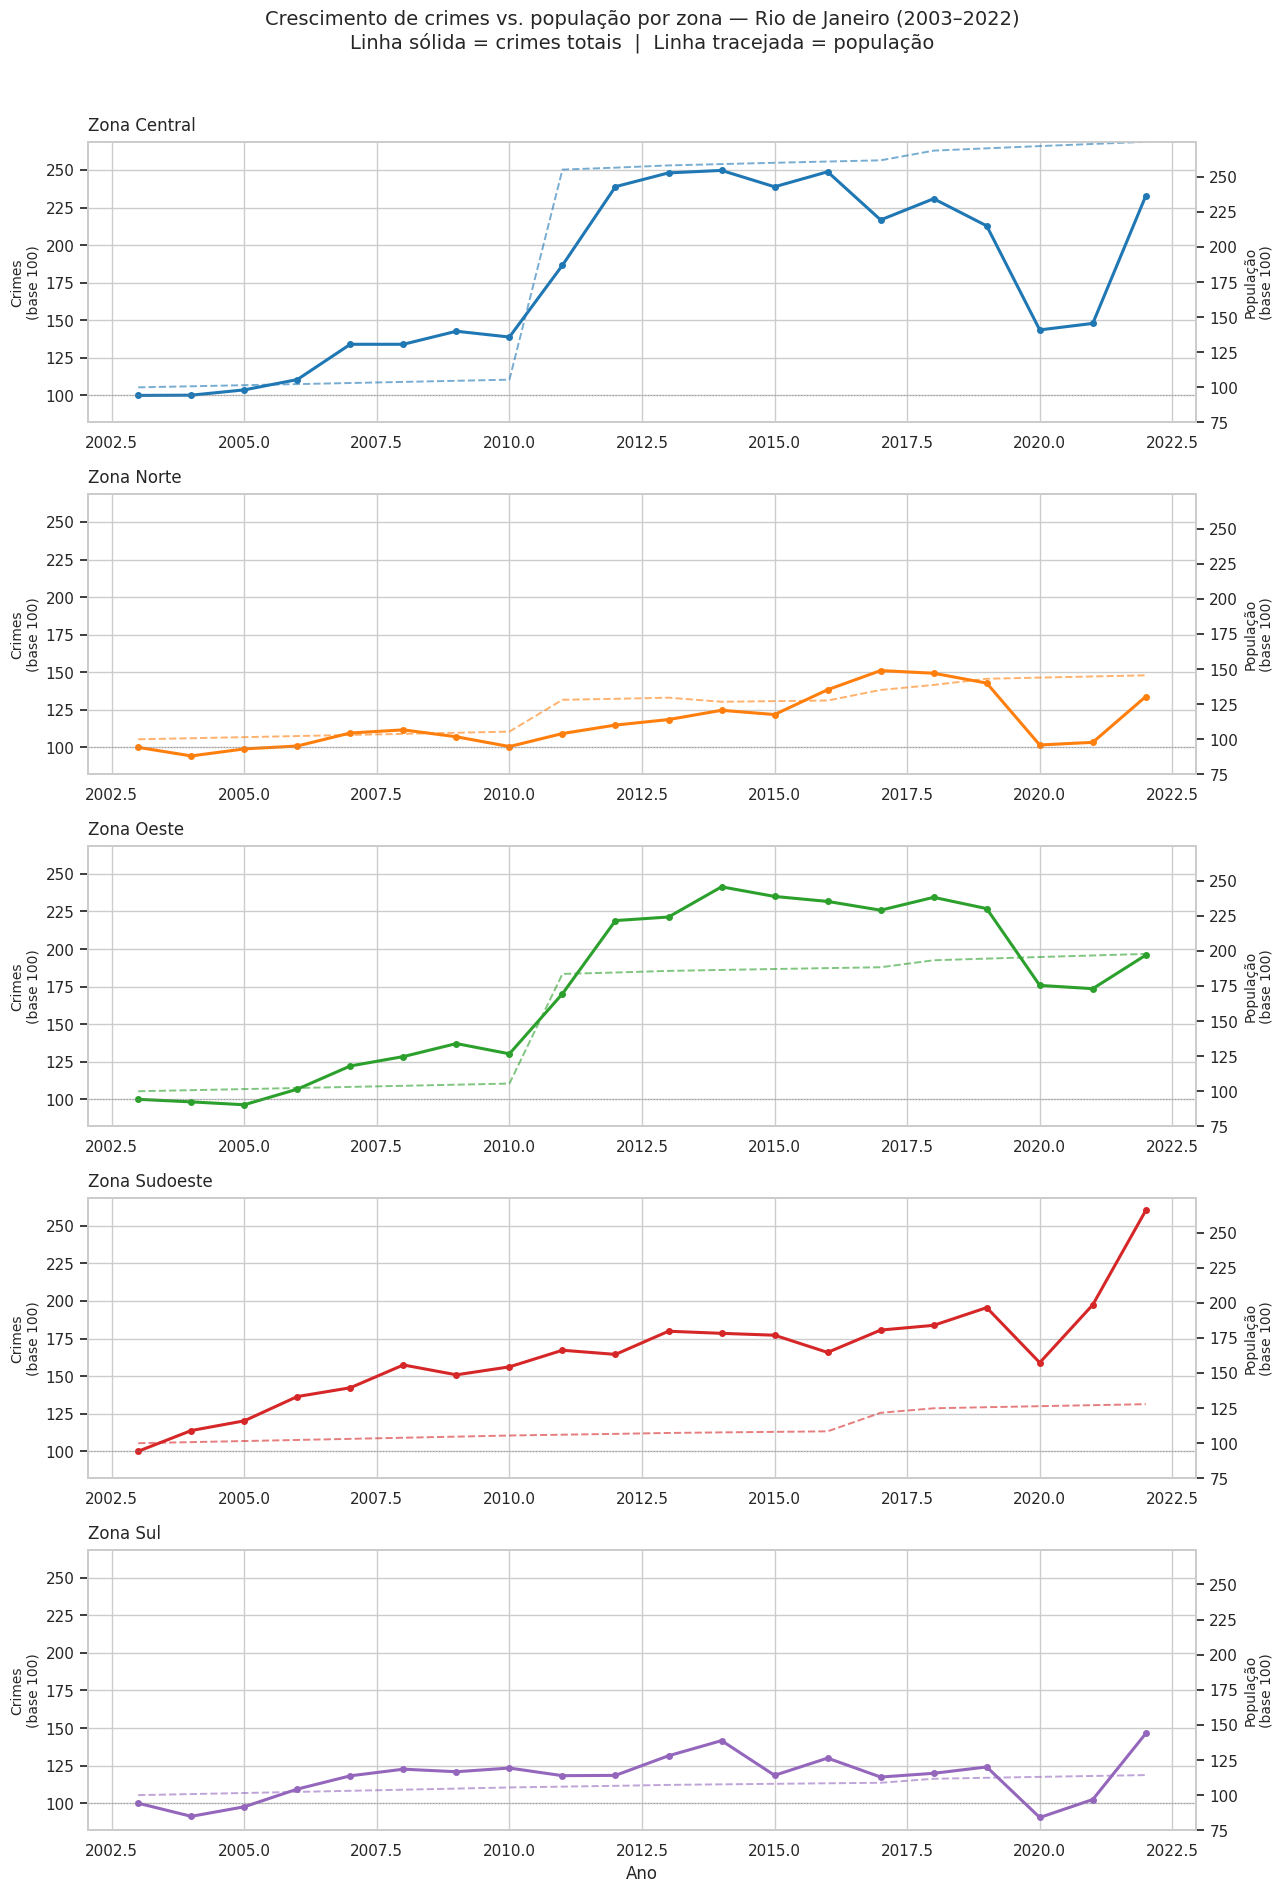


Variação acumulada 2003–2022 (índice base 100):
         Zona  Índice de crimes (2022)  Índice populacional (2022)
Zona Sudoeste               260.252738                  127.775804
 Zona Central               232.782971                   274.82667
   Zona Oeste               195.954402                  197.775279
     Zona Sul               146.419009                  114.279787
   Zona Norte               133.814853                  145.544888


In [ ]:
# Estilo
sns.set_theme(style='whitegrid', palette='tab10')

zonas = sorted(df_com_pop['Zona'].unique())
cores = sns.color_palette('tab10', n_colors=len(zonas))
cor_por_zona = dict(zip(zonas, cores)) # Dicionário de cores por zona

# Escala fixa e honesta para população em todos os subplots
pop_min = df_com_pop['indice_pop'].min()
pop_max = df_com_pop['indice_pop'].max()

# Estruturando subplots para cada zona:
fig, axes = plt.subplots(
    nrows=len(zonas),   # 5 zonas
    ncols=1,   # Alinhados verticalmente numa coluna
    figsize=(13, 3.8 * len(zonas)),   # Altura da figura está baseada na quantidade de zonas
    sharex=False,   # Cada subplot tem seu eixo x independente
    sharey=True   # Mesma escala de Y para todos os subplots, tornando-os comparáveis.
)

# Garante compatibilidade se houver só 1 zona
if len(zonas) == 1:
    axes = [axes]

for ax, zona in zip(axes, zonas):
    dados = df_com_pop[df_com_pop['Zona'] == zona].sort_values('ano')  # Filtrando apenas a 'zona atual' do loop
    cor = cor_por_zona[zona]

    # Segundo eixo y, à direita para população
    ax_pop = ax.twinx()
    ax_pop.grid(False)

    # Linha sólida = índice de crimes, com o eixo na esquerda
    # ax = Eixo da criminalidade
    ax.plot(
        dados['ano'], dados['indice_crimes'],
        color=cor, linewidth=2.2,
        marker='o', markersize=4,
        label='Índice de crimes'
    )

    # Linha tracejada = índice populacional, com o eixo na direita
    # ax_pop = Eixo da população
    ax_pop.plot(
        dados['ano'], dados['indice_pop'],
        color=cor, linewidth=1.4,
        linestyle='--', alpha=0.6,
        label='Índice populacional'
    )

    # Escala fixa do eixo direito
    ax_pop.set_ylim(75, pop_max)   #     WIP

    # Linha base = 100
    # Ponto de partida em y = 100 (ano de 2003)
    ax.axhline(100, color='gray', linewidth=0.8, linestyle=':', alpha=0.7)

    # Título individual
    ax.set_title(zona, loc='left', fontsize=12, pad=8)   # Zona atual

    # Labels do eixo esquerdo
    ax.set_ylabel('Crimes\n(base 100)', fontsize=10)

    # Labels do eixo direito
    ax_pop.set_ylabel('População\n(base 100)', fontsize=10)

# Label do eixo X só no final
axes[-1].set_xlabel('Ano', fontsize=12)

# Título geral
fig.suptitle(
    'Crescimento de crimes vs. população por zona — Rio de Janeiro (2003–2022)\n'
    'Linha sólida = crimes totais  |  Linha tracejada = população',
    fontsize=14,
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.98])   # Espaçamento
plt.show()

# ── Resumo 2022 ──
print()
print('Variação acumulada 2003–2022 (índice base 100):')

resumo = df_com_pop[df_com_pop['ano'] == 2022][['Zona', 'indice_crimes', 'indice_pop']].copy()
resumo.columns = ['Zona', 'Índice de crimes (2022)', 'Índice populacional (2022)']
resumo = resumo.sort_values('Índice de crimes (2022)', ascending=False).reset_index(drop=True)

print(resumo.to_string(index=False))

Zona Central
* Dois platôs de nível populacional
* Mesmo desconsiderando o vale que a pandemia em 2020 representa, a criminalidade demonstra uma sutil queda desde 2017.

Zona Norte
* Crescimento da criminalidade e crescimento da população igualmente sutis.
* Crime supera a população em crescimento, mas apenas por um breve período antes da pandemia.

Zona Oeste
* O crime cresce acima da taxa da população mas só até meados de 2010. A partir daí, a distância é relativamente estável, sendo impactada apenas pela pandemia.

Zona Sudoeste
* Crescimento da criminalidade significativamente maior que o crescimento populacional ao longo do período registrado.
* Pico de criminalidade em 2022 é um destaque curioso da zona sudoeste.
* O salto populacional presente nos outros gráficos ocorre em 2016 ao invés de 2011.


Zona Sul
* Como na zona norte, a população cresce mas a criminalidade permanece relativamente estável, aumentando distância entre os dois índices.

### Índices de Categoria de Crimes 2003-2022

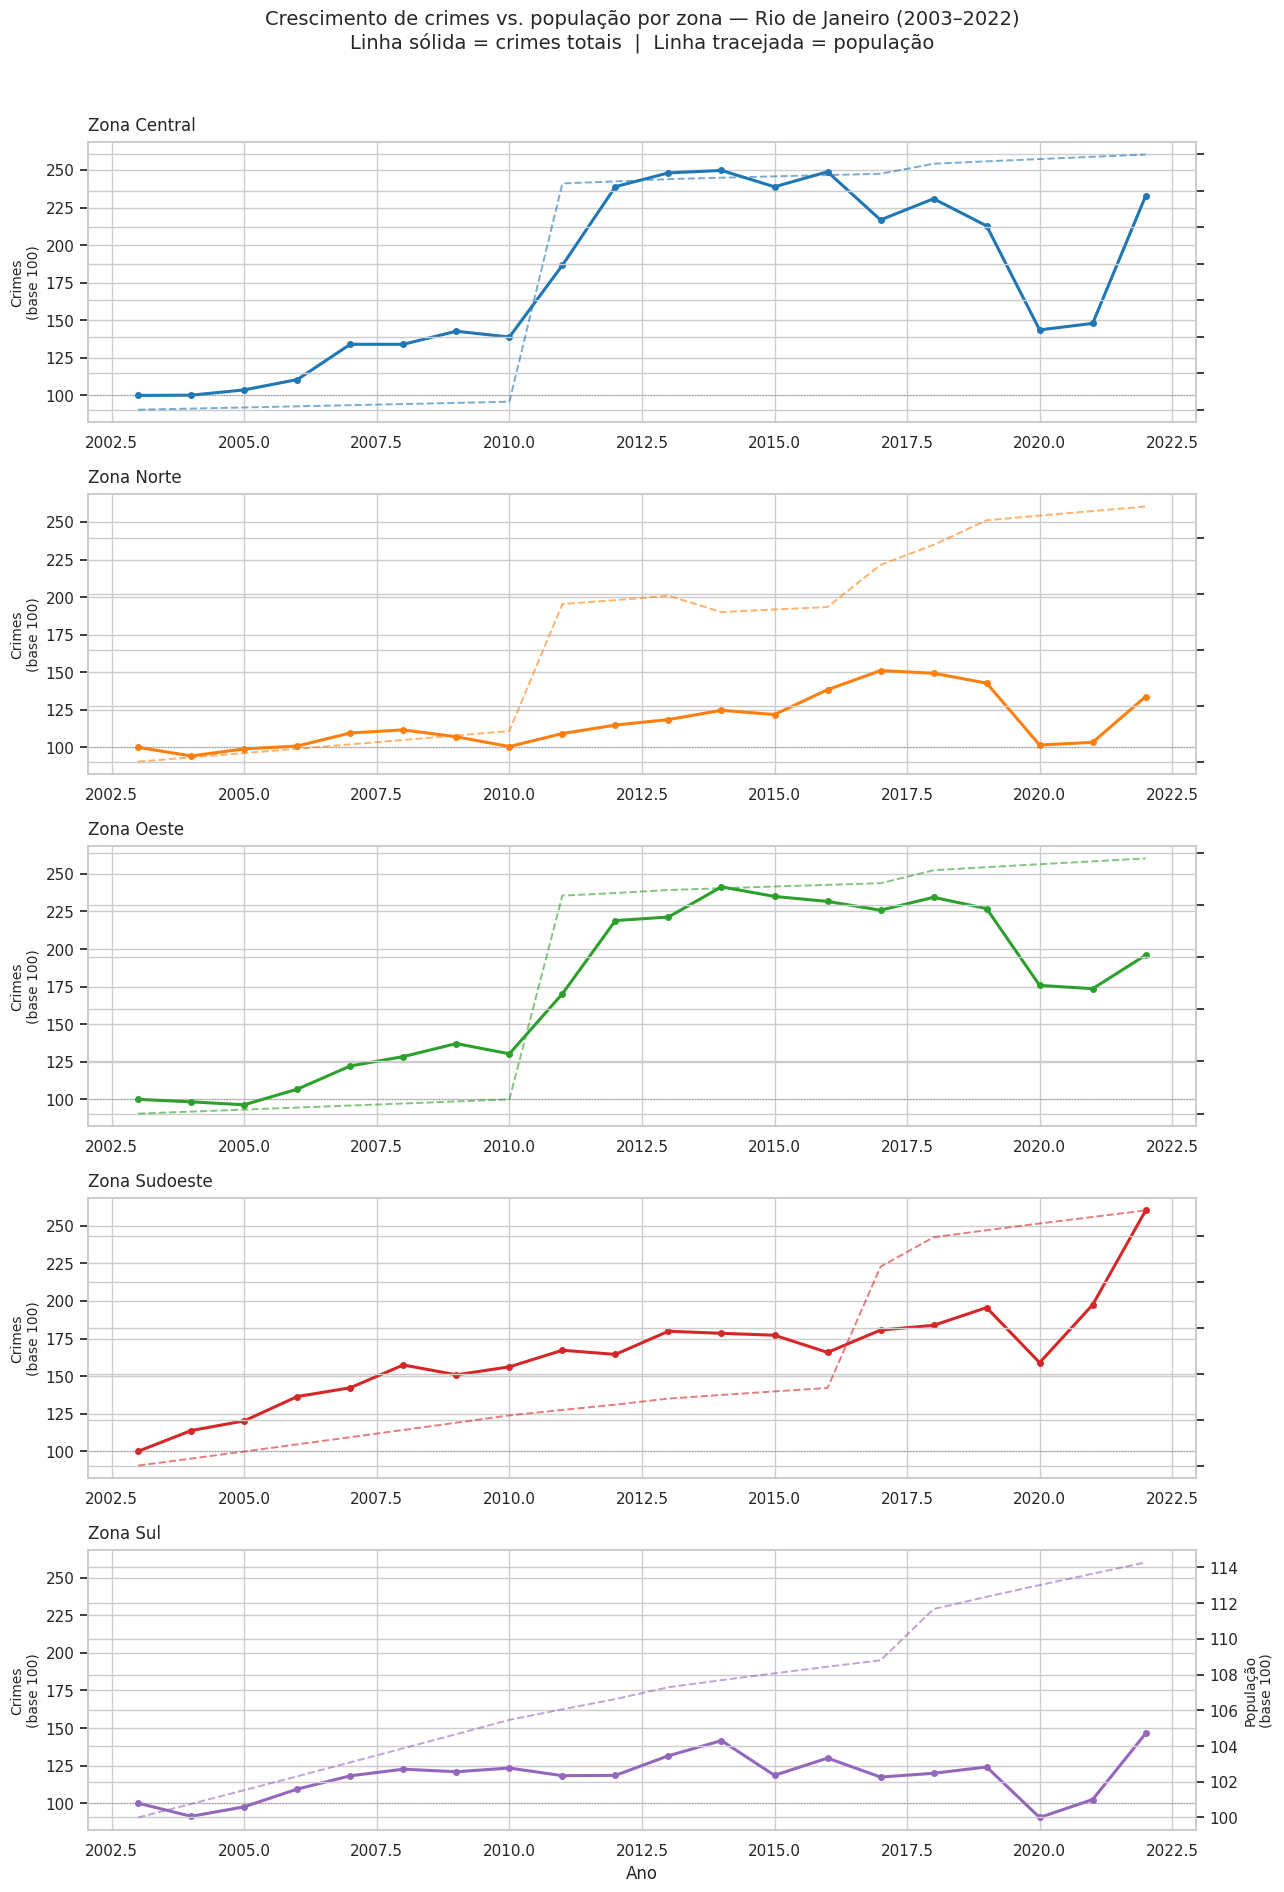


Variação acumulada 2003–2022 (índice base 100):
         Zona  Índice de crimes (2022)  Índice populacional (2022)
Zona Sudoeste               260.252738                  127.775804
 Zona Central               232.782971                   274.82667
   Zona Oeste               195.954402                  197.775279
     Zona Sul               146.419009                  114.279787
   Zona Norte               133.814853                  145.544888


In [ ]:
# Estilo
sns.set_theme(style='whitegrid', palette='tab10')

zonas = sorted(df_com_pop['Zona'].unique())
cores = sns.color_palette('tab10', n_colors=len(zonas))
cor_por_zona = dict(zip(zonas, cores)) # Dicionário de cores por zona

# Escala fixa e honesta para população em todos os subplots
pop_min = df_com_pop['indice_pop'].min()
pop_max = df_com_pop['indice_pop'].max()

# Estruturando subplots para cada zona:
fig, axes = plt.subplots(
    nrows=len(zonas),   # 5 zonas
    ncols=1,   # Alinhados verticalmente numa coluna
    figsize=(13, 3.8 * len(zonas)),   # Altura da figura está baseada na quantidade de zonas
    sharex=False,   # Cada subplot tem seu eixo x independente
    sharey=True   # Mesma escala de Y para todos os subplots, tornando-os comparáveis.
)

# Garante compatibilidade se houver só 1 zona
if len(zonas) == 1:
    axes = [axes]

for ax, zona in zip(axes, zonas):
    dados = df_com_pop[df_com_pop['Zona'] == zona].sort_values('ano')  # Filtrando apenas a 'zona atual' do loop
    cor = cor_por_zona[zona]

    # Segundo eixo y, à direita para população
    ax_pop = ax.twinx()
    ax_pop.grid(False)

    # Linha sólida = índice de crimes, com o eixo na esquerda
    # ax = Eixo da criminalidade
    ax.plot(
        dados['ano'], dados['indice_crimes'],
        color=cor, linewidth=2.2,
        marker='o', markersize=4,
        label='Índice de crimes'
    )

    # Linha tracejada = índice populacional, com o eixo na direita
    # ax_pop = Eixo da população
    ax_pop.plot(
        dados['ano'], dados['indice_pop'],
        color=cor, linewidth=1.4,
        linestyle='--', alpha=0.6,
        label='Índice populacional'
    )

    # Escala fixa do eixo direito (honesta)
    ax_pop.set_ylim(pop_min, pop_max)

    # Linha base = 100
    # Ponto de partida em y = 100 (ano de 2003)
    ax.axhline(100, color='gray', linewidth=0.8, linestyle=':', alpha=0.7)

    # Título individual
    ax.set_title(zona, loc='left', fontsize=12, pad=8)   # Zona atual

    # Labels do eixo esquerdo
    ax.set_ylabel('Crimes\n(base 100)', fontsize=10)

    # Labels do eixo direito
    ax_pop.set_ylabel('População\n(base 100)', fontsize=10)

# Label do eixo X só no final
axes[-1].set_xlabel('Ano', fontsize=12)

# Título geral
fig.suptitle(
    'Crescimento de crimes vs. população por zona — Rio de Janeiro (2003–2022)\n'
    'Linha sólida = crimes totais  |  Linha tracejada = população',
    fontsize=14,
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.98])   # Espaçamento
plt.show()

# ── Resumo 2022 ──
print()
print('Variação acumulada 2003–2022 (índice base 100):')

resumo = df_com_pop[df_com_pop['ano'] == 2022][['Zona', 'indice_crimes', 'indice_pop']].copy()
resumo.columns = ['Zona', 'Índice de crimes (2022)', 'Índice populacional (2022)']
resumo = resumo.sort_values('Índice de crimes (2022)', ascending=False).reset_index(drop=True)

print(resumo.to_string(index=False))

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

### *Crimes Violentos*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

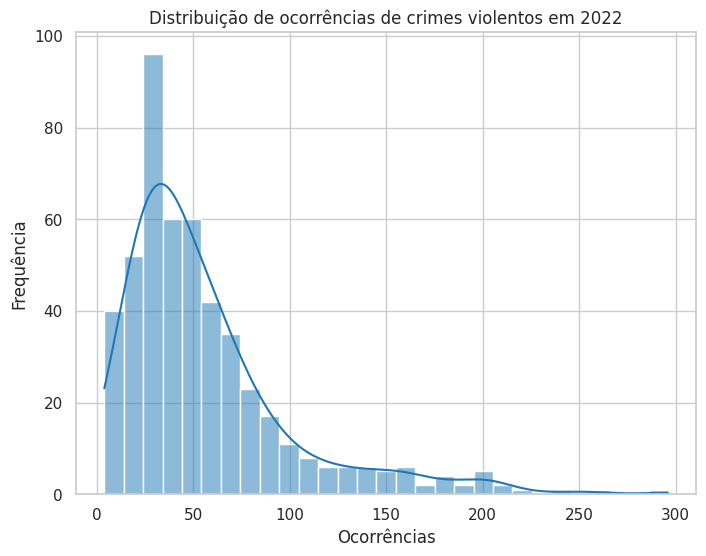

In [ ]:
# Na cidade como um todo, no ano de 2022
# X = Ocorrências
# Y = Linhas

plt.figure(figsize=(8, 6))
sns.histplot(df[df['ano'] == 2022]['violentos'], kde=True)
plt.title('Distribuição de ocorrências de crimes violentos em 2022')
plt.xlabel('Ocorrências')
plt.ylabel('Frequência')
plt.show()

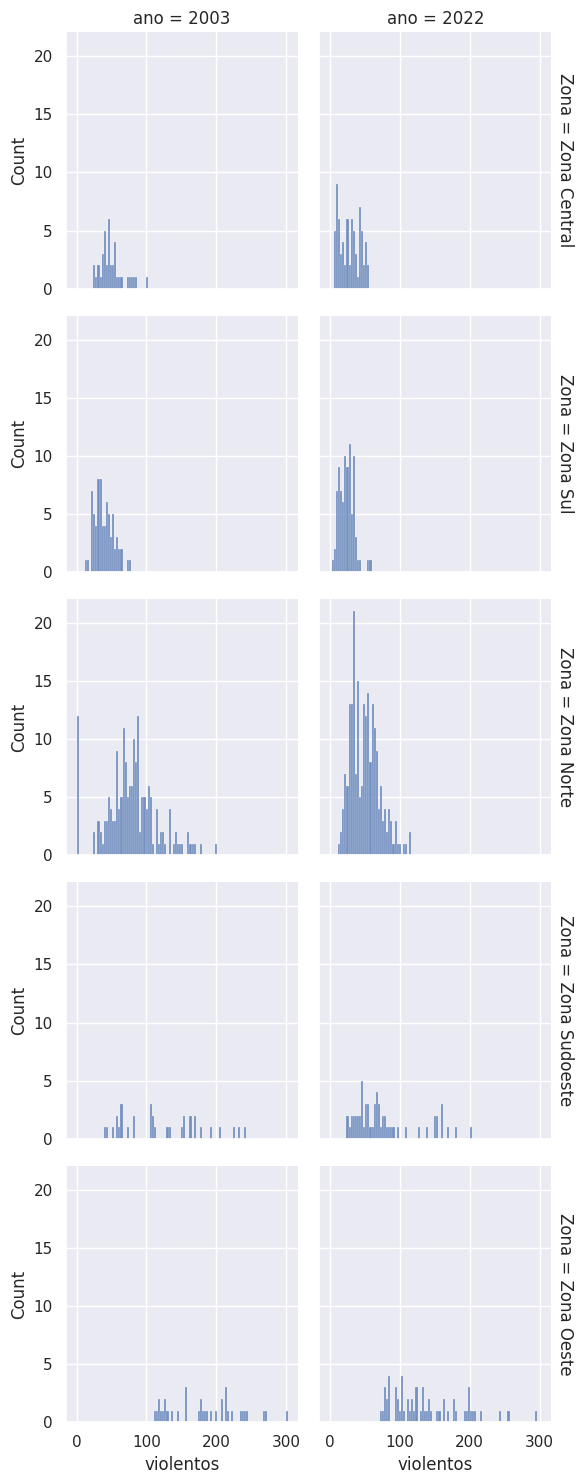

In [ ]:
sns.set_theme(style="darkgrid")
df_filtrado = df[df['ano'].isin([2003, 2022])]
g = sns.displot(
    df_filtrado,
    x="violentos",
    col="ano",
    row="Zona",
    binwidth=3,
    height=3,
    facet_kws=dict(margin_titles=True),
)




O histograma mostra a distribuição do comprimento da sépala. A curva de densidade estimada (KDE) nos indica que a distribuição parece bimodal ou multimodal, indicando que as espécies podem ter comprimentos de sépalas diferentes.

### *sepal width*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma do comprimento da sépala (um dos atributos)
sns.histplot(df['sepal width (cm)'], kde=True)
plt.title('Distribuição da Largura da Sépala')
plt.xlabel('Largura da Sépala (cm)')
plt.ylabel('Frequência')
plt.show()

KeyError: 'sepal width (cm)'

<Figure size 800x600 with 0 Axes>

Quais impressões você tem sobre a distribuição do atributo 'sepal width'?

## Boxplot

Para entender as diferenças entre as espécies, devemos olhar como se comportam os valores quando agrupadas por espécie. Isso nos permite comparar a média, mediana e desvio padrão de cada característica para Iris setosa, Iris versicolor e Iris virginica, além de visualizar suas distribuições por meio de boxplots.


In [ ]:
# Estatísticas descritivas agrupadas por espécie
df.groupby('species').describe()

### *petal length* por Espécie


In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='species', y='petal length (cm)', data=df)
plt.title('Comprimento da Pétala por Espécie')
plt.xlabel('Espécie')
plt.ylabel('Comprimento da Pétala (cm)')
plt.show()

O boxplot do comprimento da pétala por espécie demonstra claramente que a Iris setosa tem pétalas significativamente mais curtas do que as outras duas espécies. Há uma sobreposição entre Iris versicolor e Iris virginica, mas as medianas e as caixas indicam uma distinção.

### *petal width* por Espécie

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='species', y='petal width (cm)', data=df)
plt.title('Largura da Pétala por Espécie')
plt.xlabel('Espécie')
plt.ylabel('Largura da Pétala (cm)')
plt.show()

Quais impressões o boxplot trouxe?

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

In [ ]:
# Matriz de correlação
print("\nMatriz de Correlação:")
df.iloc[:, :4].corr()

In [ ]:
plt.figure(figsize=(8, 6))
# mapa de calor das variáveis numéricas
sns.heatmap(df.iloc[:, :4].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do Iris Dataset')
plt.show()

O mapa de calor da matriz de correlação revela fortes correlações positivas entre *petal length* e *petal width*, bem como entre *sepal length* e *petal length*/*petal width*. Isso sugere que essas características se movem juntas, o que é útil para a seleção de características.

## Tratamento de Valores Nulos

O dataset Iris original não possui valores nulos. No entanto, o tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [ ]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset Iris:")
df.isnull().sum()

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [ ]:
# Separar features (X) e target (y)
X = df.drop('species', axis=1)
y = df['species']

In [ ]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.



In [ ]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()

In [ ]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['sepal length (cm)'], kde=True)
plt.title('Distribuição do Comprimento da Sépala (Normalizado)')
plt.xlabel('Comprimento da Sépala Normalizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *sepal length* após a normalização mostra que os valores foram escalados para o intervalo de 0 a 1, mantendo a forma da distribuição original.

## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [ ]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [ ]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['sepal length (cm)'], kde=True)
plt.title('Distribuição do Comprimento da Sépala (Padronizado)')
plt.xlabel('Comprimento da Sépala Padronizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *sepal length* após a padronização mostra que os valores foram transformados para ter uma média próxima de zero e um desvio padrão de um, centralizando a distribuição.

## Outras Transformações e Etapas de Pré-Processamento

Outras etapas de pré-processamento incluem a seleção de características, redução de dimensionalidade (como PCA) ou criação de novas características (feature engineering). O que você faria a mais?



# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

**O crime no Rio de Janeiro proliferou acima do crescimento populacional? Onde? Em quais categorias?**

=>

## Hipótese 2


**Haveriam localidades 'outlier' em que o crime cresceu além da média da zona?**

=>

## Hipótese 3

**Haveriam tipos de crimes 'outlier' que cresceram além da média de suas categorias?**

=>

## Hipótese 4

**Os tipos de crime mais frequentes significativamente divergem entre zonas?**

=>

# Conclusão

A análise e pré-processamento do dataset Iris demonstram a importância de entender a estrutura dos dados antes da modelagem. O dataset é limpo e balanceado, com características numéricas bem definidas que permitem uma clara separação entre as espécies, especialmente a Iris setosa. A análise exploratória revelou correlações importantes entre as características e a eficácia de visualizações como boxplots para distinguir as classes. As etapas de normalização e padronização são fundamentais para preparar os dados para diversos algoritmos de aprendizado de máquina, garantindo que o modelo possa aprender eficientemente com as relações presentes nos dados.

As três hipóteses levantadas foram validadas:

1.   *As diferentes espécies de Íris podem ser distinguidas com base nas medições de suas sépalas e pétalas?* Sim, dado as análises que fizemos no boxplot, observamos um comportamento muito claro e distinto.

2.   *Existe uma correlação entre comprimento da pétala e largura da pétala?* Existe forte correlação entre os atributos *petal length* e *petal width*.

3.   *A espécie Iris setosa é mais facilmente separável das outras duas espécies?* Sim, devido às suas características distintas de menor comprimento e largura da pétala.